In [1]:
from src import *
from myutils import *

In [ ]:
def loadnpz(file):
    file = os.path.expanduser(file)
    npz = np.load(file, allow_pickle=True)
    meta = npz['metadata'].item()
    meta_ = MetaData(meta.measurement, meta.ground_truth, 'frequency', meta.amplitude, meta.pwm_duty, timestamp=meta.timestamp)

    dic = {}
    for k in npz.files:
        if k.lower() == 'noise':
            dic['background'] = npz[k]
        
        elif k.lower() == 'frequency_estimates':
            dic['estimates_a'] = npz[k]

        elif k.lower() == 'metadata':
            dic[k] = meta_

        elif k.lower() == 'velocity_estimates':
            pass

        elif k.lower() == 'start_point_estimates':
            pass

        else:
            dic[k] = npz[k]

    return Estimates(**dic)

In [ ]:
from glob import glob

In [ ]:
tree = [
    'noisy/di_5px',
    'noisy/spade_5px',

    '0noise/di_5px',
    '0noise/spade_5px',

    '0noise/di_3px',
    '0noise/spade_3px',
]

In [ ]:
def main(_folder):
    src = os.path.join('__estimates__.old', _folder)
    dst = os.path.join('__estimates__', _folder)
    for file in tqdm(glob(src+'/*')):
        c = loadnpz(file)
        c.savez(dst)


In [8]:
c = LoadEstimates(r'__estimates__\noisy\spade_5px\spade_5px_f0.2_d100.npz')

In [3]:
c.time_domain

array([[ 0.89900079,  0.93070651,  0.81459938, ...,  0.93394533,
        -1.21708843, -1.05738235],
       [ 0.68267895,  0.77454254,  0.93139531, ...,  0.9292636 ,
        -1.27024514, -1.06872808],
       [ 0.84969274,  0.95226415,  0.85550508, ...,  0.9805031 ,
        -1.03551897, -0.97792159],
       ...,
       [ 0.74581658,  0.60210246,  0.68563971, ...,  0.74174347,
        -1.23436231, -0.99634596],
       [ 0.84523425,  0.70298614,  0.85629409, ...,  0.76166368,
        -1.25062851, -1.20886408],
       [ 1.02108616,  0.83274134,  0.53203791, ...,  0.83505557,
        -1.14184496, -1.11637579]])

In [9]:
td1 = td_estimator('spade', c.cropped_data, c.background, method='mle', standardize=False)
td2 = td_estimator('spade', c.cropped_data, c.background, method='lse', standardize=False)
td3 = td_estimator('spade', c.cropped_data, c.background, method='zhou2023', standardize=False)

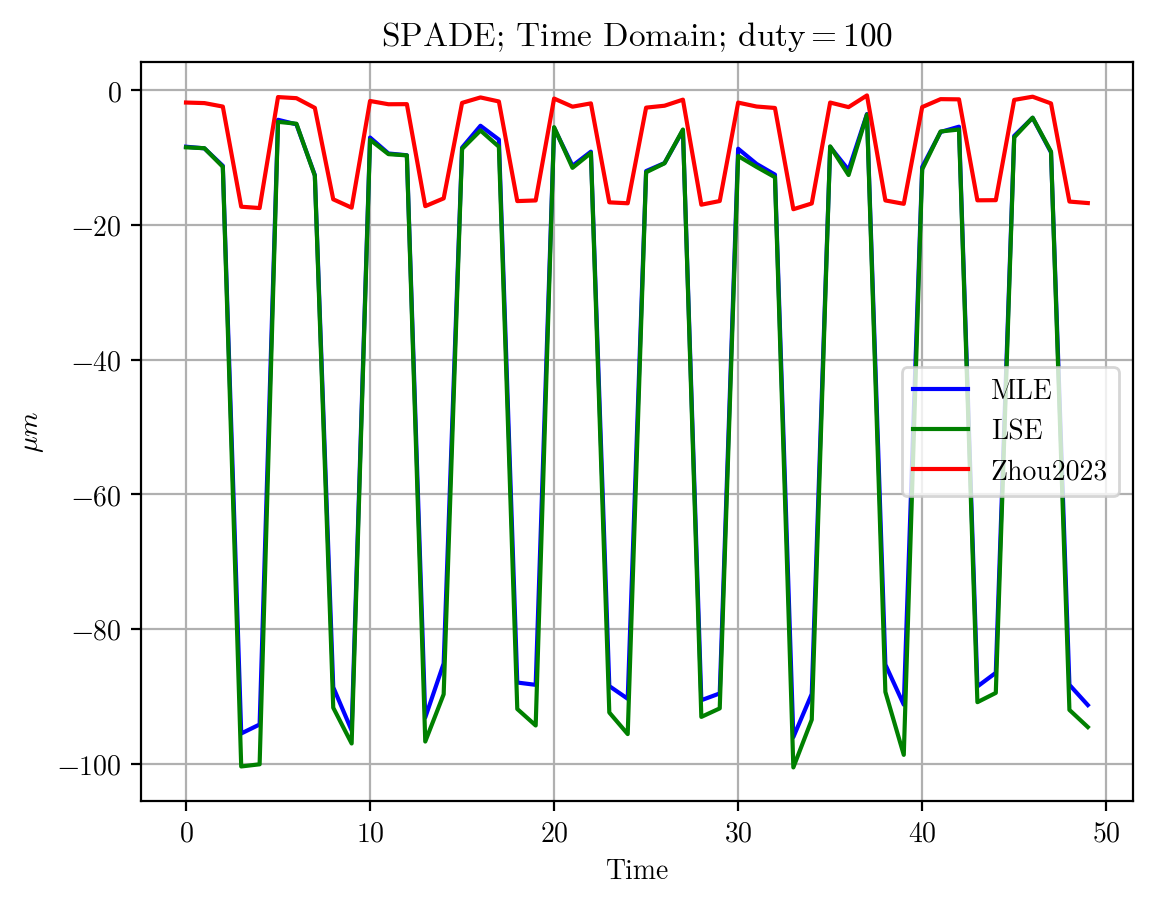

In [10]:
plot(td1.mean(0), label='MLE')
plot(td2.mean(0), label='LSE', xlabel='Time', ylabel=r'$\mu m$')
plot(td3.mean(0), title=r'SPADE; Time Domain; ${\rm duty} = 100$', label='Zhou2023')

In [2]:
c = LoadEstimates(r'__estimates__\noisy\di_5px\di_5px_f0.2_d100.npz')

In [3]:
td1 = td_estimator('di', c.cropped_data, c.background, method='mle', standardize=False)
td2 = td_estimator('di', c.cropped_data, c.background, method='lse', standardize=False)
td3 = td_estimator('di', c.cropped_data, c.background, method='simple', standardize=False)

476.2191060000021 93.31658071999999
476.2191060000021 93.31658071999999


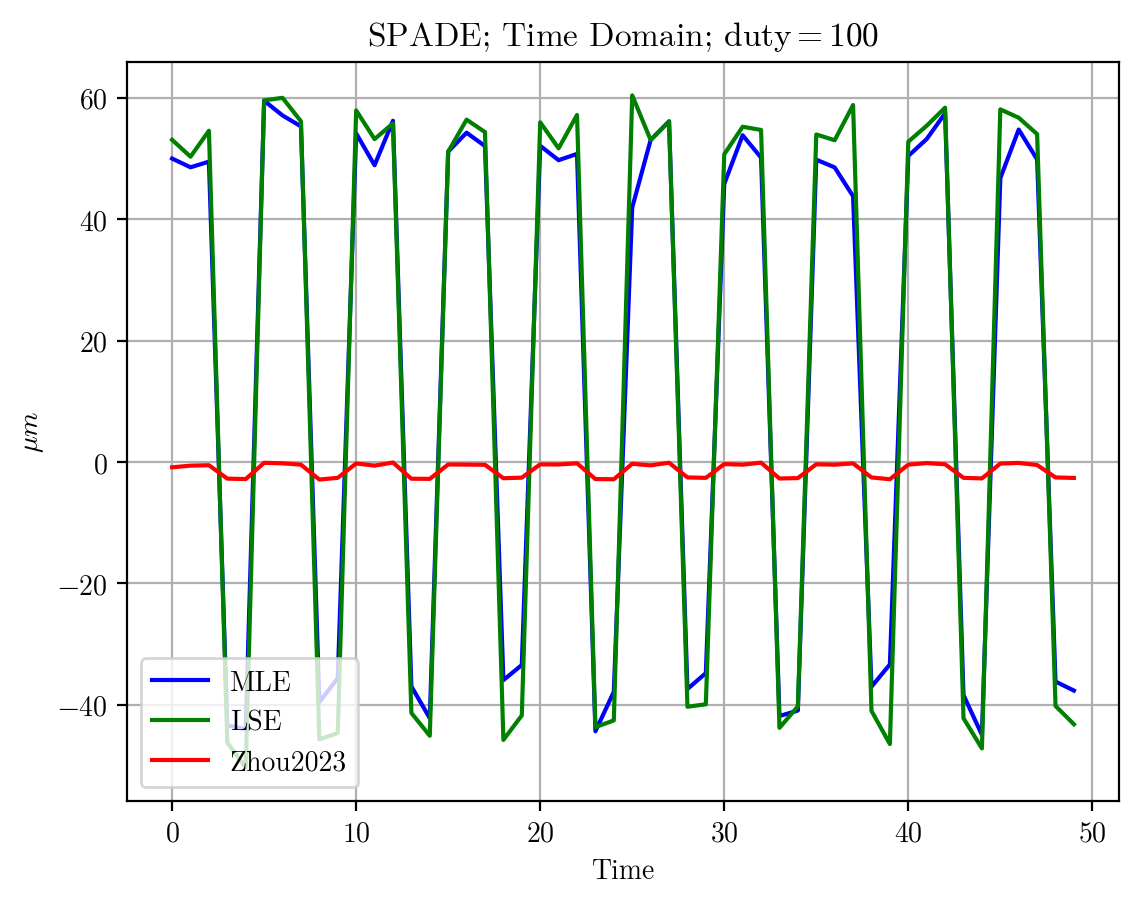

In [4]:
plot(td1.mean(0), label='MLE')
plot(td2.mean(0), label='LSE', xlabel='Time', ylabel=r'$\mu m$')
plot(td3.mean(0), title=r'SPADE; Time Domain; ${\rm duty} = 100$', label='Zhou2023')

In [3]:
Simulator(MetaData('DI', 0, 'frequency', 0)).gen(noise=100)

(array([[ 973., 1027., 1182., ..., 1000., 1264., 1045.],
        [ 945., 1173., 1091., ..., 1118., 1055., 1200.],
        [ 945., 1036., 1082., ..., 1082., 1200., 1182.],
        ...,
        [ 982., 1036., 1073., ..., 1145., 1173., 1291.],
        [1227., 1173., 1364., ..., 1064.,  982.,  982.],
        [1018., 1145., 1082., ...,  991., 1200., 1218.]]),
 array([[ 973., 1027., 1182., ..., 1000., 1264., 1045.],
        [ 945., 1173., 1091., ..., 1118., 1055., 1200.],
        [ 945., 1036., 1082., ..., 1082., 1200., 1182.],
        ...,
        [ 982., 1036., 1073., ..., 1145., 1173., 1291.],
        [1227., 1173., 1364., ..., 1064.,  982.,  982.],
        [1018., 1145., 1082., ...,  991., 1200., 1218.]]))

In [35]:
a, b = Simulator(MetaData('DI', 0, 'frequency', 20)).gen(noise=100, sample_length=1000)

In [36]:
td1 = td_estimator('di', a, b.mean(-1), method='mle', standardize=False)
td2 = td_estimator('di', a, b.mean(-1), method='lse', standardize=False)
td3 = td_estimator('di', a, b.mean(-1), method='simple', standardize=False)

399.98640000000097 100.00742113043478
399.98640000000097 100.00742113043478


In [38]:
[td1.mean(), td2.mean(), td3.mean()]

[-2.8780550689237567, -1.852433543232771, -2.2445096106162525]

In [39]:
td1.var(), td2.var(), td3.var()

(1463.462738346877, 1472.6761745543479, 3.5884770506124215)

In [40]:
DI.SIGMA ** 2 / 400

26.5225

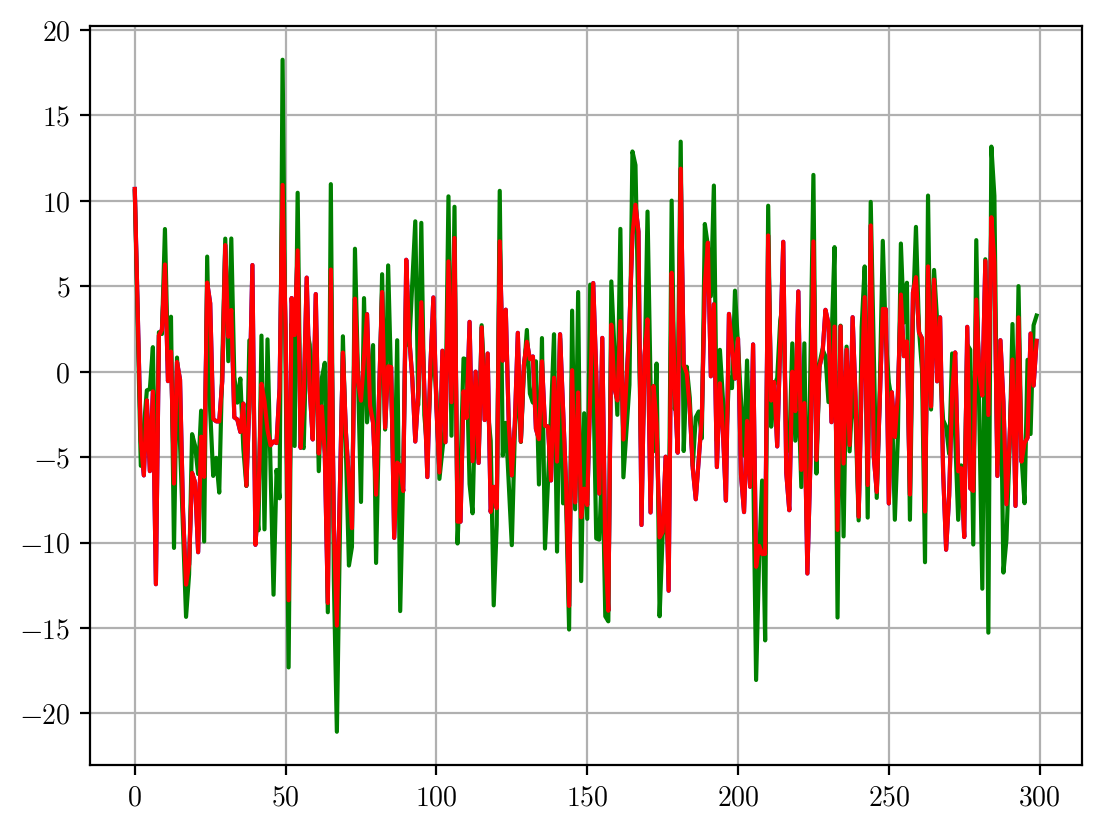

In [81]:
plot(td1)
plot(td2)
plot(td3)


In [5]:
td1[30, 7] / qCMOS.PIXEL_SIZE + 100

760.0670980462762

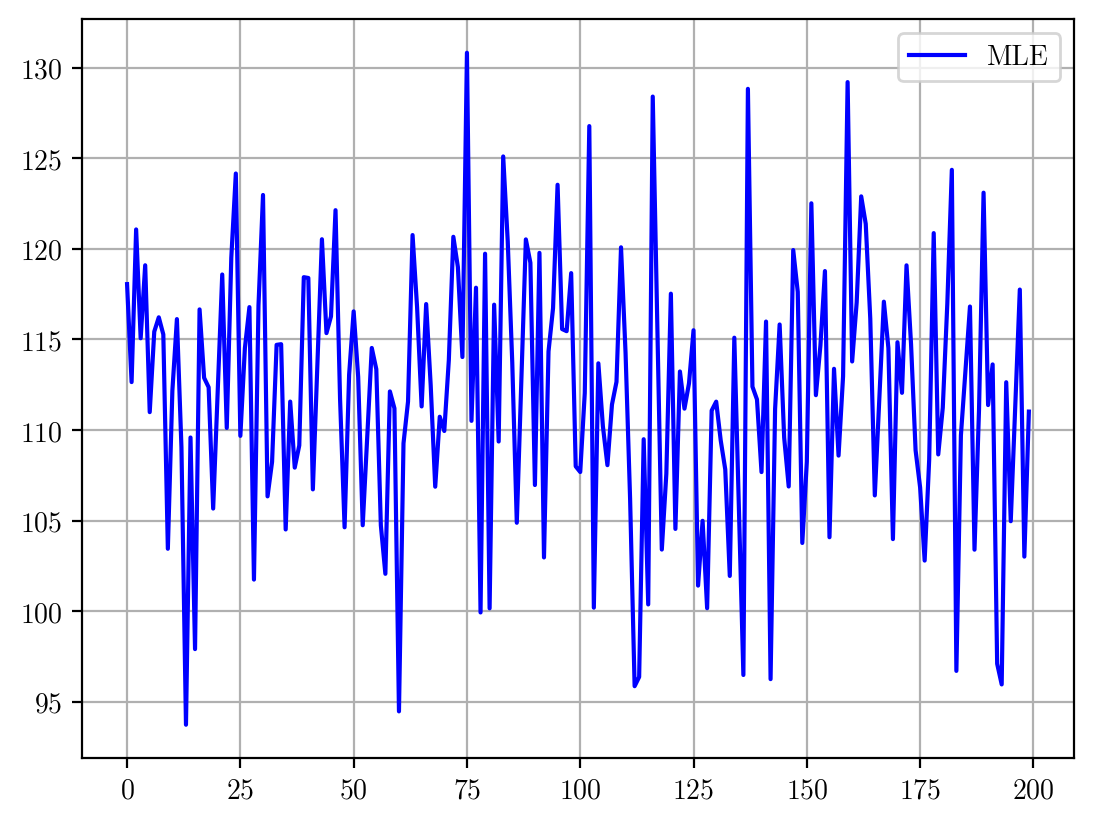

In [5]:
plot((td1[:, 7])/qCMOS.PIXEL_SIZE + 100, label='MLE')
# plot(td2.mean(0), label='LSE', xlabel='Time', ylabel=r'$\mu m$')
# plot(td3.mean(0), title=r'DI; Time Domain; ${\rm duty} = 90$', label='Simple (Mass Center )')

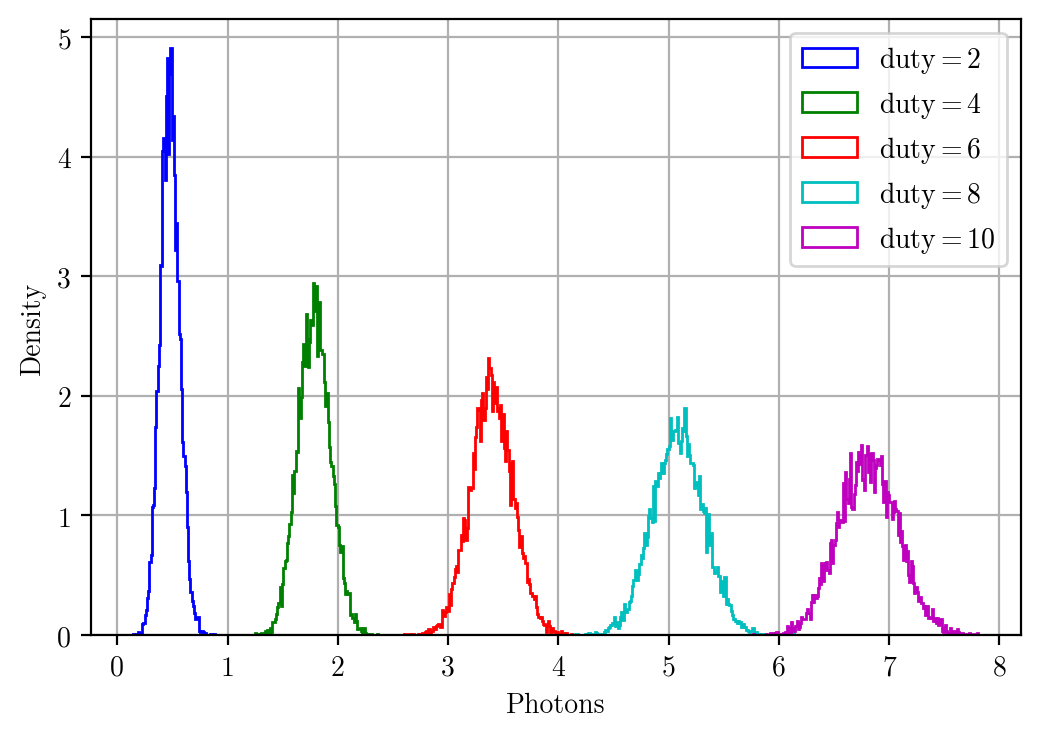

In [37]:
for d in (2, 4, 6, 8, 10):
    c = LoadEstimates(rf'__estimates__\noisy\di_5px\di_5px_f0.2_d{d}.npz')
    hist(qCMOS.convert2photons(np.ravel(c.background)), bins=10*round(c.background.max() - c.background.min()), label=r'${\rm duty}' + f' = {d}$')
    plt.xlabel('Photons')
    plt.ylabel('Density')

In [27]:
from myutils import *

In [168]:
from src import *
from scipy.optimize import minimize, fsolve, curve_fit
from scipy.special import erf, factorial



def _di_td(data: np.ndarray, background: np.ndarray, method: str):
    origin_shape = data.shape
    flatten = data.reshape(-1, origin_shape[-1])
    works = flatten.shape[0]
    pixels = origin_shape[-1]

    pn = qCMOS.convert2photons(flatten)
    mass_center = pn @ np.arange(pixels) / pn.sum(-1)

    if method.lower() == 'simple':
        time_domain = mass_center

    elif method.lower() in ('mle', 'lse'):
        b = qCMOS.convert2photons(background).mean()
        I0 = (pn - b).sum(-1).mean(0)
        _sig = DI.SIGMA / qCMOS.PIXEL_SIZE

        def _uk(x_, theta):
            z1 = (x_ - theta + 0.5) / (_sig * (2**0.5))
            z2 = (x_ - theta - 0.5) / (_sig * (2**0.5))
            DeltaE = erf(z1)/2 - erf(z2)/2
            return I0 * DeltaE + b

        def _grad_nll(frame):
            x = np.arange(pixels).astype(float)
            def wrapper(theta):
                z1 = (x - theta + 0.5) / (_sig * (2**0.5))
                z2 = (x - theta - 0.5) / (_sig * (2**0.5))
                DeltaE = erf(z1)/2 - erf(z2)/2
                uk = I0 * DeltaE + b
                return - np.sum(frame * np.log(uk) - uk - (frame * np.log(frame) - frame)), \
                       - I0/(_sig*tau**0.5) * np.sum((-np.exp(-z1**2) + np.exp(-z2**2)) * (frame/uk - 1))
            return wrapper

        time_domain = []
        for i in range(works):
            if method.lower() == 'mle':
                opt = minimize(_grad_nll(pn[i]), x0=mass_center[i], jac=True, bounds=[(0, pixels)], tol=1e-8, options={'maxls': 100})
                result = [opt.x.item(), None, opt.success, opt.message]

            elif method.lower() == 'lse':
                result = curve_fit(_uk, xdata=np.arange(pixels), ydata=pn[i], p0=mass_center[i], full_output=True, maxfev=800, xtol=1e-8)
            
            if result[2]:
                time_domain.append(result[0])
            else:
                raise RuntimeError(f'Time-Domain estimator: {method.upper()} is not converged, {result[3]}')

    else:
        raise ValueError('di_method must be simple, lse or mle')
    
    return np.array(time_domain).reshape(*origin_shape[:-1])





# The camera pixels are used as the length unit, so the pixel size is 1.
def _standardize(time_domain: np.ndarray, standardize: bool):
    if standardize:
        std = time_domain.std()
        mean = time_domain.mean()
        time_domain = (time_domain - mean) / std
    return time_domain


def _spade_td(data: np.ndarray, background: np.ndarray, method: str):
    temp = qCMOS.convert2photons(data)
    k = temp[..., 0] / temp[..., 1]
    zhou2023 = - 2 * SPADE.SIGMA * (1 - np.sqrt(k)) / (1 + np.sqrt(k))

    if method.lower() == 'sub':
        return data[..., 1] - data[..., 0]
    
    elif method.lower() == 'zhou2023':
        return - zhou2023
    
    elif method.lower() in ('lse', 'mle'):
        origin_shape = data.shape
        flatten = data.reshape(-1, origin_shape[-1])
        works = flatten.shape[0]

        pn = qCMOS.convert2photons(flatten)
        b = qCMOS.convert2photons(background).mean()
        I0 = (pn - b).sum(-1).mean(0)

        def _uk(q, theta):
            xi = theta / (2 * SPADE.SIGMA)
            return I0/2 * (xi + (-1)**q)**2 * np.exp(-xi**2) + b
        
        def _grad_nll(frame):
            def wrapper(theta):
                xi = theta / (2 * SPADE.SIGMA)
                k = np.array([0, 1])
                return - np.sum(frame * np.log(_uk(k, theta)) - _uk(k, theta) - (frame * np.log(frame) - frame)), \
                         I0/(2*SPADE.SIGMA)*np.exp(-xi**2)*((xi + 1) * (xi**2 + xi - 1) * (frame[0]/_uk(0, theta) - 1) + 
                                                            (xi - 1) * (xi**2 - xi - 1) * (frame[1]/_uk(1, theta) - 1))
            return wrapper

        time_domain = []
        for i in range(works):
            if method.lower() == 'mle':
                opt = minimize(_grad_nll(pn[i]), 
                               x0 = np.ravel(zhou2023)[i], 
                               jac = True, 
                               bounds = [(-2*SPADE.SIGMA, 2*SPADE.SIGMA)], 
                               tol = 1e-8, 
                               options = {'maxls': 100})

                result = [opt.x.item(), None, opt.success, opt.message]

            elif method.lower() == 'lse':
                result = curve_fit(_uk, xdata=np.array([0, 1]), ydata=pn[i], p0=np.ravel(zhou2023)[i], full_output=True, maxfev=800, xtol=1e-8)
            
            if result[2]:
                time_domain.append(result[0])
            else:
                raise RuntimeError(f'Time-Domain estimator: {method.upper()} is not converged, {result[3]}')
            
        return - np.array(time_domain).reshape(*origin_shape[:-1])

    else:
        raise ValueError('spade_method must be sub, zhou2023, lse, or mle')



In [23]:
c = LoadEstimates(r'__estimates__\0noise\spade_3px\spade_3px_f0.29_d0.npz')
c.estimates_a.var() * c.photons.mean()

0.005752231224798454

In [55]:
td1 = _spade_td(c.cropped_data, c.background, method='mle')
td2 = _spade_td(c.cropped_data, c.background, method='lse')
td3 = _spade_td(c.cropped_data, c.background, method='zhou2023')
td4 = _spade_td(c.cropped_data, c.background, method='sub')

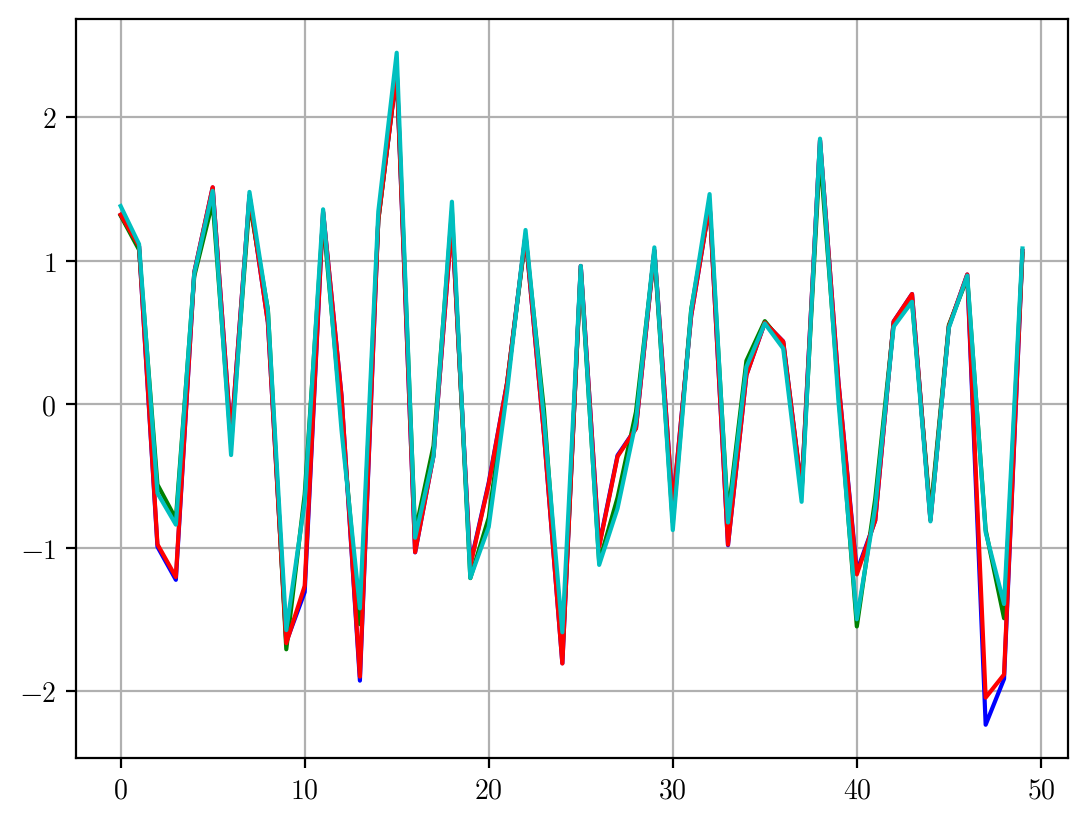

In [64]:

i=196
plot(_standardize(td1, True)[i])
plot(_standardize(td2, True)[i])
plot(_standardize(td3, True)[i])
plot(_standardize(td4, True)[i])


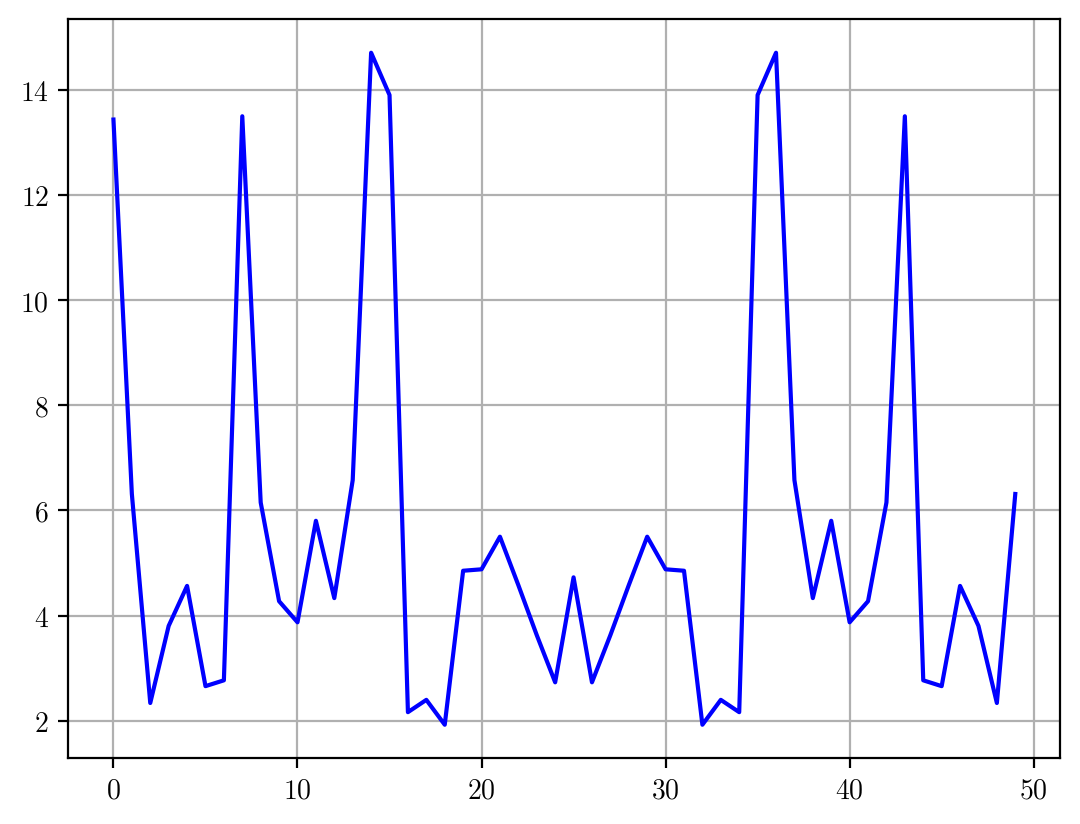

In [79]:
plot(np.abs(np.fft.fft(_standardize(td4, True)[195])))

In [95]:
_standardize(_standardize(td1, True)[195], True)

array([ 1.70303517,  0.0117019 , -1.23914573, -0.86861461,  1.29514796,
        1.32299857, -0.70693463,  1.21035877,  0.59093874, -0.34659777,
       -0.93584054, -0.42485739, -0.44490096, -1.34488951,  0.38669692,
        0.96011823, -1.17796416, -1.659921  ,  1.09126495, -1.71635528,
       -0.74351628,  1.04489606,  0.98884417, -0.14226819, -1.09473326,
        0.27966598, -1.12365167, -0.3695812 ,  1.31693955,  0.96520168,
       -0.48684787,  0.52193891, -0.39451877, -1.6366863 , -1.32627555,
        1.82426355,  0.67463226, -0.66036128,  0.8347563 ,  0.72747406,
       -1.23177711,  0.00828228,  1.19425359,  1.5890317 , -0.48419712,
        0.86260679, -0.13024034, -0.86525631, -0.54790851,  0.69879326])

In [96]:
freq_estimator(_standardize(_standardize(td1, True)[195], True), method='fft')

0.14

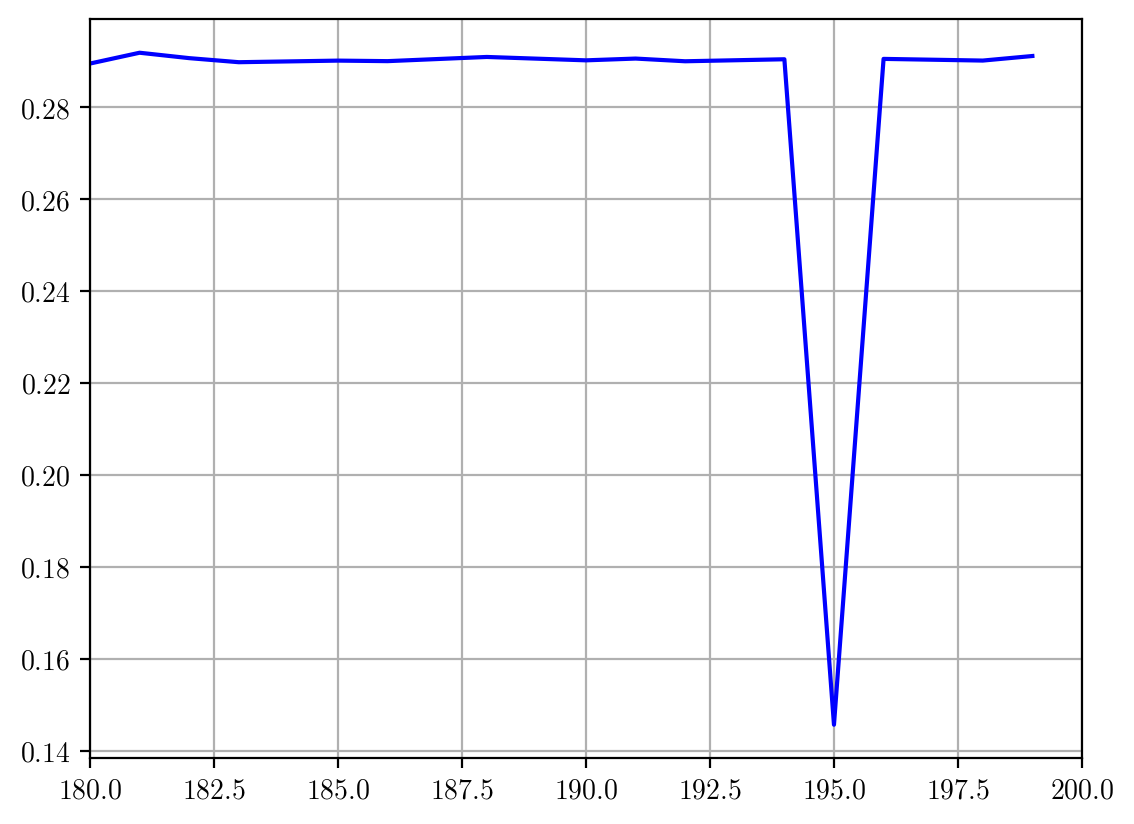

In [83]:
plot(c.estimates_a, xlim=(180, 200))

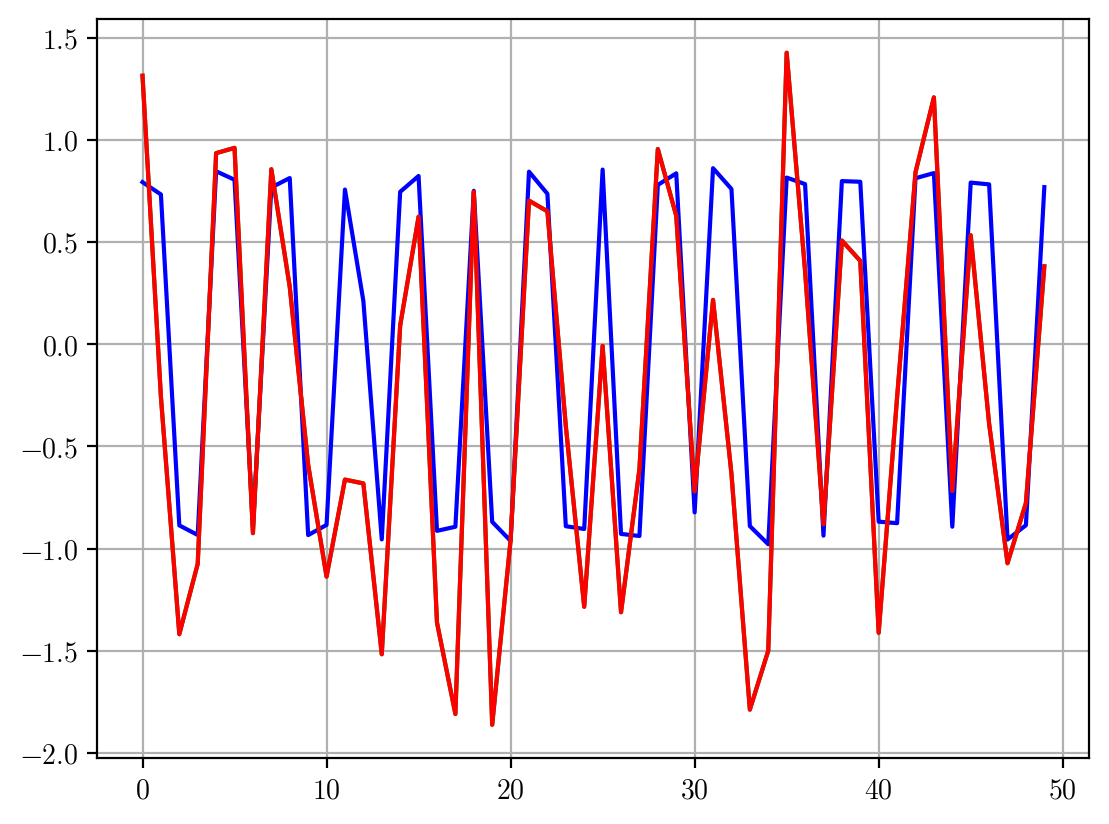

In [52]:
plot(c.time_domain.mean(0))
plot(c.time_domain[195])
plot(_standardize(td, True)[195])

In [137]:
freq_estimator(smooth_signal(td1[195], window_size=5), method='fft')

0.02

In [138]:
def freq_estimator(sample: np.ndarray):
    # Use FFT as pre-estimator, if method is fft, retrun FFT estimates.
    l = len(sample)

    fft = np.abs(np.fft.fft(sample)[:l // 2])
    freq = np.fft.fftfreq(l, 1)[:l // 2]

    peak_index = np.argmax(fft[1:]) + 1
    pre_freq_est = freq[peak_index]
    return pre_freq_est

In [151]:
import numpy as np

def freq_estimator(sample: np.ndarray, window_type="hanning", zero_padding=0):
    """
    Estimate the frequency of a signal using FFT with windowing and zero-padding.

    Parameters:
        sample (np.ndarray): The input time-domain signal.
        window_type (str): Type of window to apply (e.g., 'hanning', 'hamming', 'blackman').
        zero_padding (int): The number of zeros to add to the signal for higher resolution.

    Returns:
        float: Estimated frequency of the signal.
    """
    l = len(sample)

    # Apply windowing function
    if window_type == "hanning":
        window = np.hanning(l)
    elif window_type == "hamming":
        window = np.hamming(l)
    elif window_type == "blackman":
        window = np.blackman(l)
    elif window_type == 'none':
        window = 1
    else:
        raise ValueError("Unknown window type. Please choose from 'hanning', 'hamming', or 'blackman'.")

    # Apply the window to the signal
    windowed_sample = sample * window

    # Zero-padding to increase frequency resolution
    n = l + zero_padding
    fft = np.abs(np.fft.fft(windowed_sample, n=n))[:n // 2]
    freq = np.fft.fftfreq(n, 1)[:n // 2]

    # Find the peak in the FFT
    peak_index = np.argmax(fft[1:]) + 1
    pre_freq_est = freq[peak_index]

    return pre_freq_est

# Example usage:
sample = np.array([1.31345547, -0.25725054, -1.41888671, -1.07478217, 0.9346591,
                   0.96052339, -0.92463334, 0.85591715, 0.28067466, -0.58999599,
                   -1.13721349, -0.66267407, -0.68128812, -1.51708876, 0.09099953,
                   0.62352396, -1.36206866, -1.80965195, 0.74531719, -1.86206129,
                   -0.95860595, 0.70225537, 0.65020115, -0.40023937, -1.28477385,
                   -0.00839788, -1.31162978, -0.61134023, 0.9548965, 0.62824486,
                   -0.72024335, 0.21659595, -0.63449922, -1.78807437, -1.49980236,
                   1.42603774, 0.35839908, -0.88138164, 0.50710295, 0.40747217,
                   -1.41204362, -0.26042627, 0.8409606, 1.20758282, -0.71778165,
                   0.53296712, -0.38906935, -1.07166338, -0.77694909, 0.3808369])
sample = _standardize(td4[195], 1)
# Example parameters
zero_padding = 1024  # Zero padding to increase resolution
window_type = "none"  # Use Hanning window

estimated_freq = freq_estimator(sample, window_type, zero_padding)
print(f"Estimated Frequency: {estimated_freq:.5f} Hz")


Estimated Frequency: 0.28957 Hz


In [132]:
from scipy.optimize import show_options
show_options('minimize', 'l-bfgs-b'.upper())

Minimize a scalar function of one or more variables using the L-BFGS-B
algorithm.

Options
-------
disp : None or int
    If `disp is None` (the default), then the supplied version of `iprint`
    is used. If `disp is not None`, then it overrides the supplied version
    of `iprint` with the behaviour you outlined.
maxcor : int
    The maximum number of variable metric corrections used to
    define the limited memory matrix. (The limited memory BFGS
    method does not store the full hessian but uses this many terms
    in an approximation to it.)
ftol : float
    The iteration stops when ``(f^k -
    f^{k+1})/max{|f^k|,|f^{k+1}|,1} <= ftol``.
gtol : float
    The iteration will stop when ``max{|proj g_i | i = 1, ..., n}
    <= gtol`` where ``proj g_i`` is the i-th component of the
    projected gradient.
eps : float or ndarray
    If `jac is None` the absolute step size used for numerical
    approximation of the jacobian via forward differences.
maxfun : int
    Maximum number of fu

In [133]:
'l-bfgs-b'.upper()

'L-BFGS-B'

In [124]:
c = LoadEstimates('__estimates__/noisy/di_5px/di_5px_f0.2_d100.npz')

In [126]:
for i in np.arange(0, 101, 2):
    c = LoadEstimates(f'__estimates__/noisy/di_5px/di_5px_f0.2_d{i}.npz')
    td1 = _di_td(c.cropped_data, c.background, 'mle')
# td2 = _di_td(c.cropped_data, c.background, 'lse')

In [120]:
td1

array([[ 99.64798952, 110.84037903, 104.43975546, ...,  99.80243457,
         92.94597708,  91.32956601],
       [106.10296978, 122.26154826, 106.07865507, ..., 114.72563571,
        100.6340895 ,  88.92004834],
       [117.16443293, 111.54386038, 104.02239661, ..., 110.97992156,
        100.36227895,  66.85031955],
       ...,
       [115.14763333, 106.14785231, 109.88187277, ..., 108.94142255,
         85.48312354,  91.48833821],
       [115.15844657, 106.48980253,  98.32140111, ..., 118.60478801,
        104.47121952,  98.00374221],
       [107.97228463,  99.55049132, 108.38787319, ..., 106.72185745,
        109.99805246,  86.38936674]])

In [379]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

def freq_estimator(sample: np.ndarray, window_type='hamming', zero_padding=1024):
    """
    Estimate the frequency of a signal using FFT with windowing and zero-padding.

    Parameters:
        sample (np.ndarray): The input time-domain signal.
        window_type (str): Type of window to apply ('hanning', 'hamming', 'blackman', 'none').
        zero_padding (int): Number of zeros to add to the signal for higher resolution.

    Returns:
        float: Estimated frequency of the signal.
    """
    l = len(sample)

    # Apply windowing function
    window_type = window_type.lower()
    if window_type == 'hanning':
        window = np.hanning(l)
    elif window_type == 'hamming':
        window = np.hamming(l)
    elif window_type == 'blackman':
        window = np.blackman(l)
    elif window_type == 'none':
        window = 1
    else:
        raise ValueError("Unknown window type. Please choose from 'hanning', 'hamming', 'blackman', or 'none'.")

    # Apply the window to the signal
    windowed_sample = (sample - sample.mean()) * window

    # Zero-padding to increase frequency resolution
    n = l + zero_padding
    fft = np.abs(np.fft.fft(windowed_sample, n=n))[:n // 2]
    fft = gaussian_filter1d(fft, sigma=2)
    freq = np.fft.fftfreq(n, 1)[:n // 2]

    # Find the peak in the FFT
    peak_index = np.argmax(fft[1:]) + 1
    pre_freq_est = freq[peak_index]

    return pre_freq_est


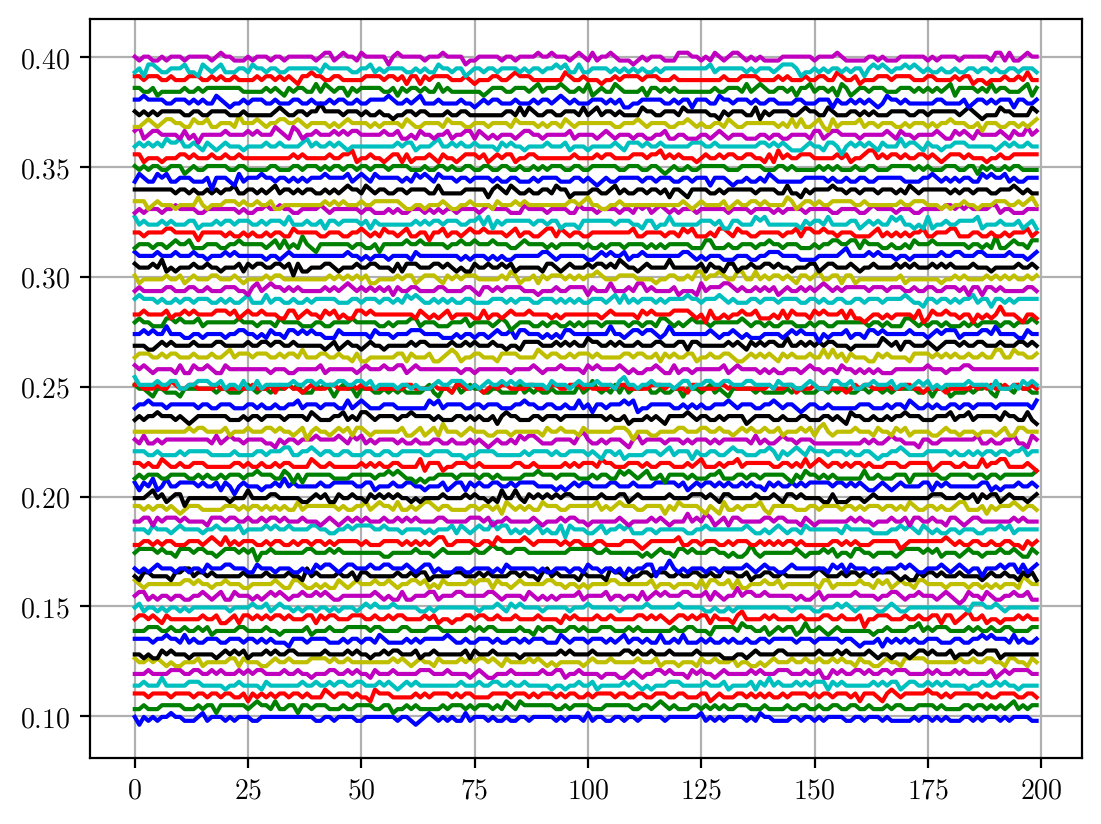

In [381]:
for j in np.linspace(0.1, 0.4, 61):
    c = LoadEstimates(rf'__estimates__\0noise\spade_3px\spade_3px_f{round(j, 5)}_d0.npz')
    plot([freq_estimator(c.time_domain[i], window_type='none', zero_padding=512) for i in range(200)])

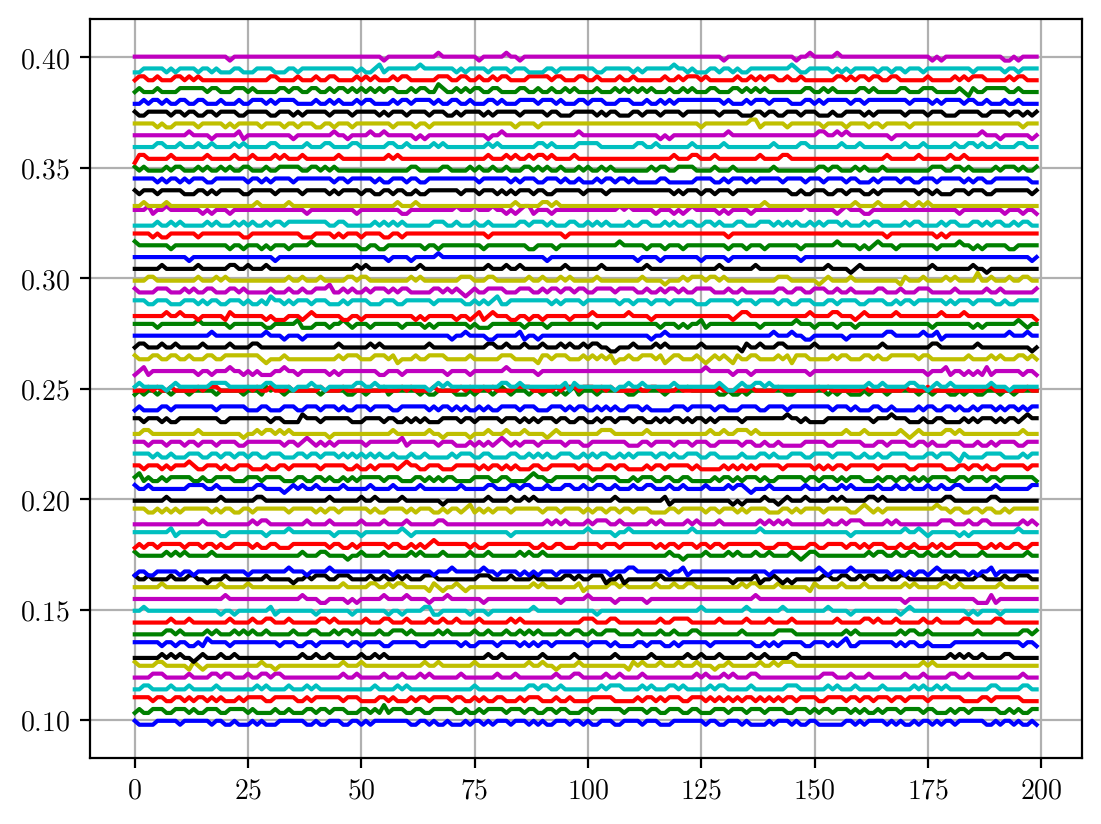

In [382]:
for j in np.linspace(0.1, 0.4, 61):
    c = LoadEstimates(rf'__estimates__\0noise\spade_5px\spade_5px_f{round(j, 5)}_d0.npz')
    plot([freq_estimator(c.time_domain[i], window_type='none', zero_padding=512) for i in range(200)])

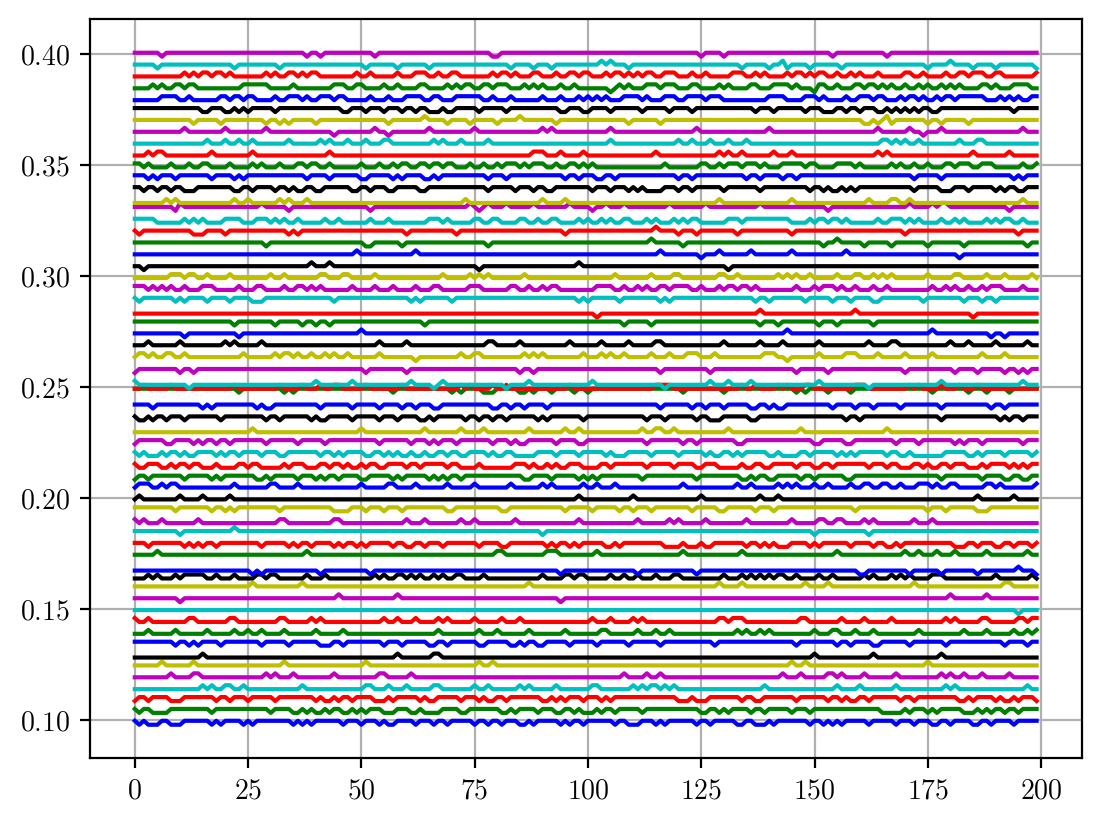

In [383]:
for j in np.linspace(0.1, 0.4, 61):
    c = LoadEstimates(rf'__estimates__\0noise\di_3px\di_3px_f{round(j, 5)}_d0.npz')
    plot([freq_estimator(c.time_domain[i], window_type='none', zero_padding=512) for i in range(200)])

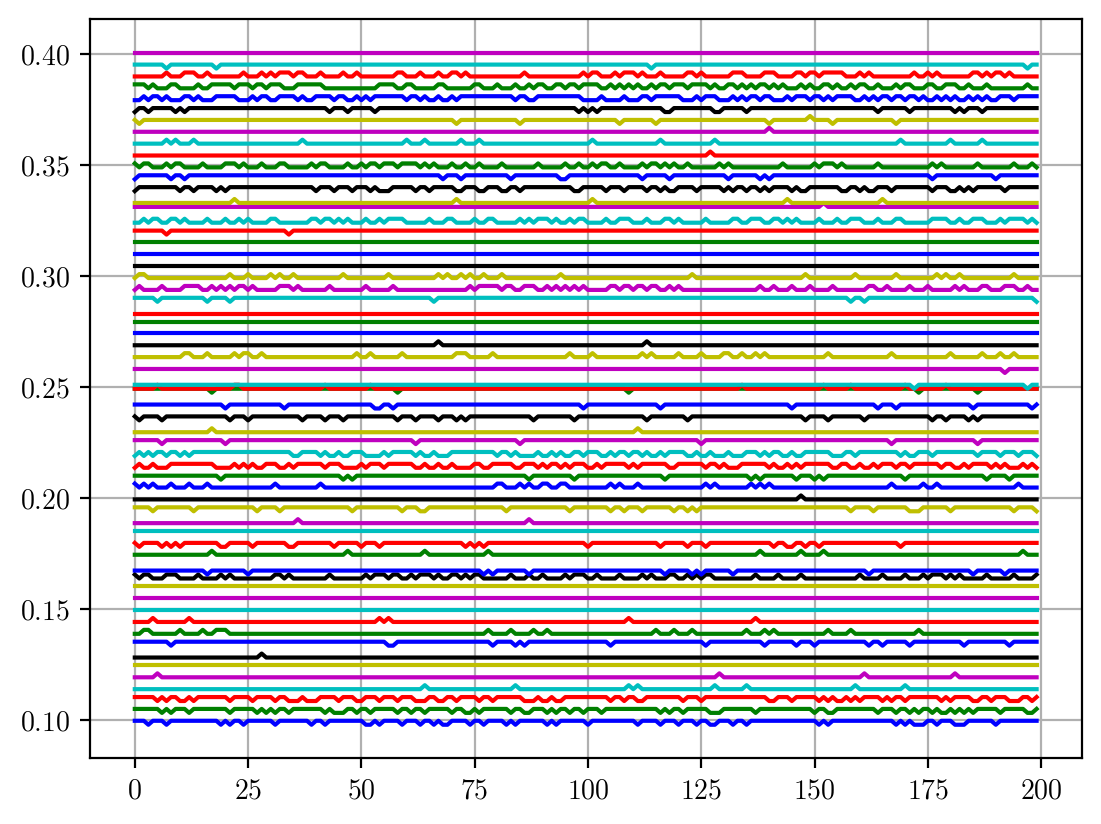

In [384]:
for j in np.linspace(0.1, 0.4, 61):
    c = LoadEstimates(rf'__estimates__\0noise\di_5px\di_5px_f{round(j, 5)}_d0.npz')
    plot([freq_estimator(c.time_domain[i], window_type='none', zero_padding=512) for i in range(200)])

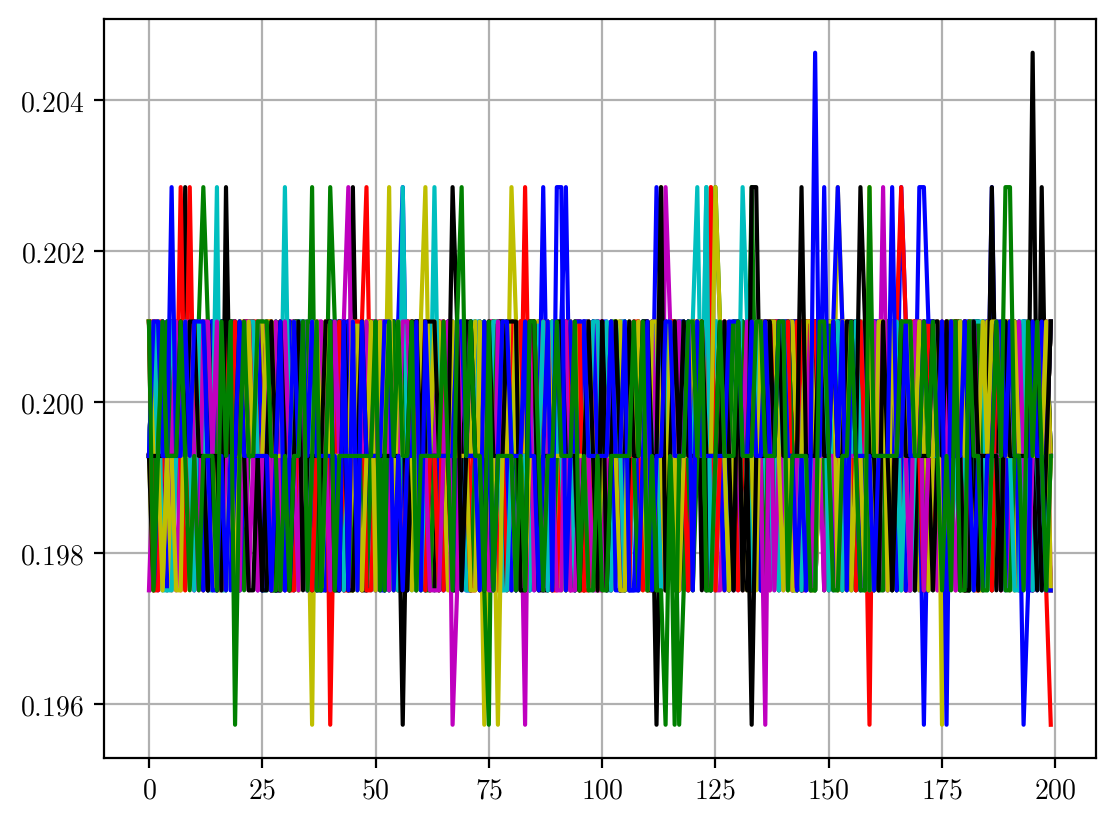

In [385]:
for j in np.linspace(0, 100, 51):
    c = LoadEstimates(rf'__estimates__\noisy\di_5px\di_5px_f0.2_d{round(j)}.npz')
    plot([freq_estimator(c.time_domain[i], window_type='none', zero_padding=512) for i in range(200)])

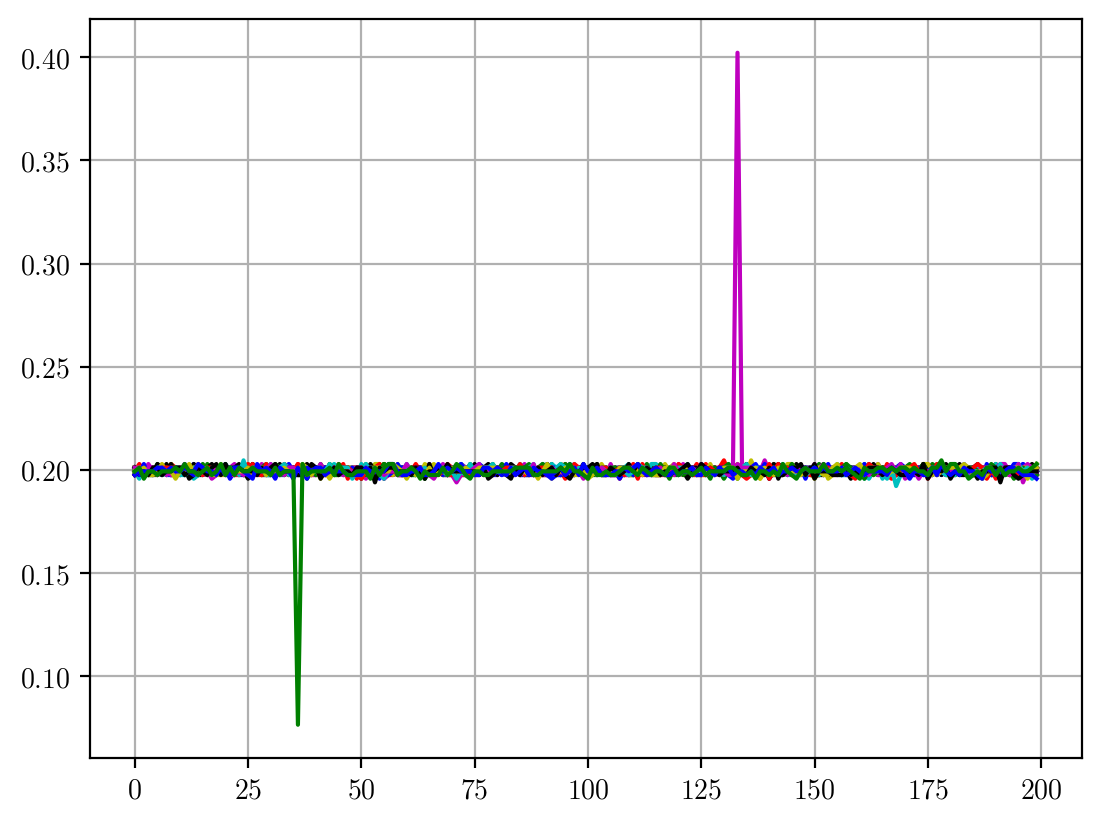

In [386]:
for j in np.linspace(0, 100, 51):
    c = LoadEstimates(rf'__estimates__\noisy\spade_5px\spade_5px_f0.2_d{round(j)}.npz')
    plot([freq_estimator(c.time_domain[i], window_type='none', zero_padding=512) for i in range(200)])

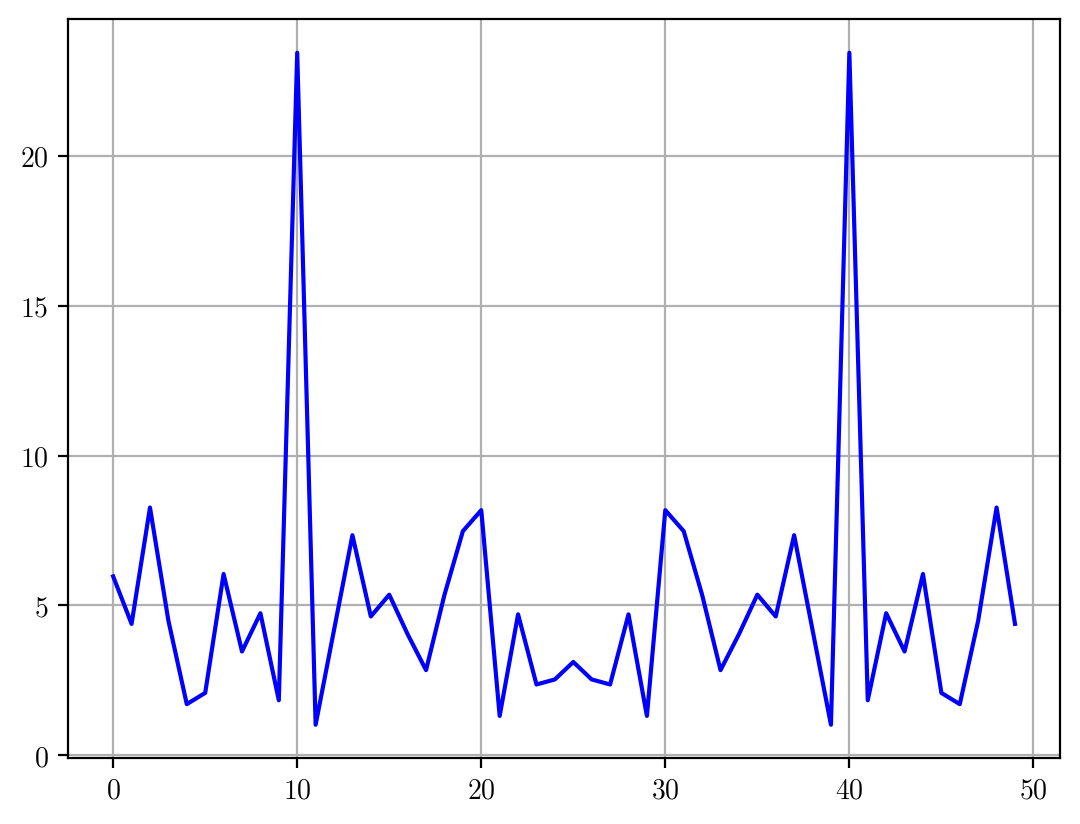

In [391]:
plot(np.abs(np.fft.fft((c.time_domain[192]))))

In [3]:
import numpy as np
from scipy.optimize import curve_fit, brute

def freq_estimator(sample: np.ndarray, method='lse'):
    """
    Estimate the frequency of a signal using brute-force and LSE (Least Squares Estimation).

    Parameters:
        sample (np.ndarray): The input time-domain signal.
        method (str): Method to use ('fft' for brute-force search result or 'lse' for least squares).

    Returns:
        float: Estimated frequency.
    """
    def waveform(n, f):
        return np.sin(2 * np.pi * f * n)

    l = len(sample)
    n = np.arange(l)

    # Search range and grid resolution for brute-force search
    search_range = (0.08, 0.42)  # Frequency range to search
    grid_points = 256         # Number of grid points in the search space

    # Brute-force search for the initial frequency
    def residual(f):
        return np.sum((sample - waveform(n, f)) ** 2)

    search_grid = (slice(search_range[0], search_range[1], (search_range[1] - search_range[0]) / grid_points),)
    best_initial_freq = brute(residual, ranges=search_grid, finish=None)
    
    if method.lower() == 'brute':
        return best_initial_freq  # Return brute-force result directly

    elif method.lower() == 'lse':
        # Use brute-force result as initial frequency for LSE
        try:
            popt, _ = curve_fit(f=waveform, xdata=n, ydata=sample, p0=[best_initial_freq], maxfev=1000)
            return popt.item()
        except RuntimeError:
            raise ValueError("Curve fitting failed; try adjusting search range or checking your data.")
    else:
        raise ValueError('Method must be "brute" or "lse".')


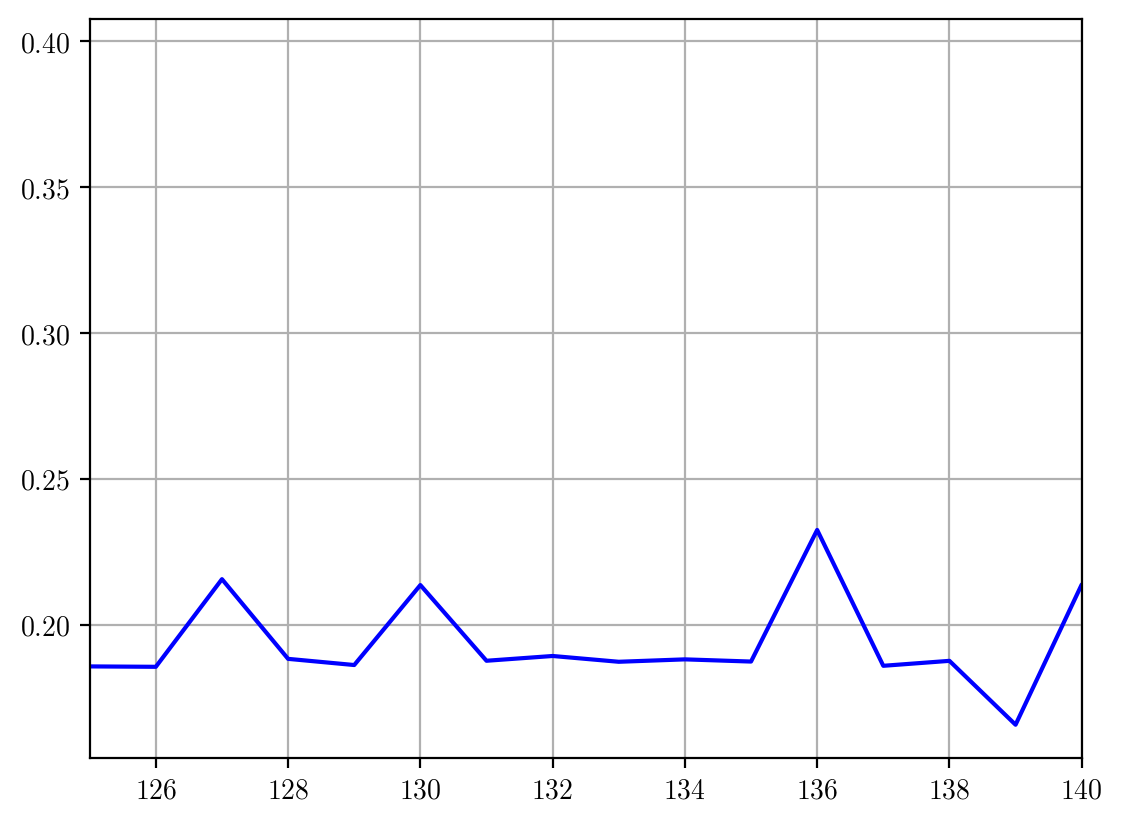

In [1]:
from src import *
from myutils import *
from scipy.special import erf, factorial

for j in (78, ):
    c = LoadEstimates(rf'__estimates__\noisy\spade_5px\spade_5px_f0.2_d{round(j)}.npz')
    c = Estimation.FromEstimates(c)
    plot([freq_estimator(c.time_domain[i], method='lse') for i in range(200)], xlim=(125, 140))

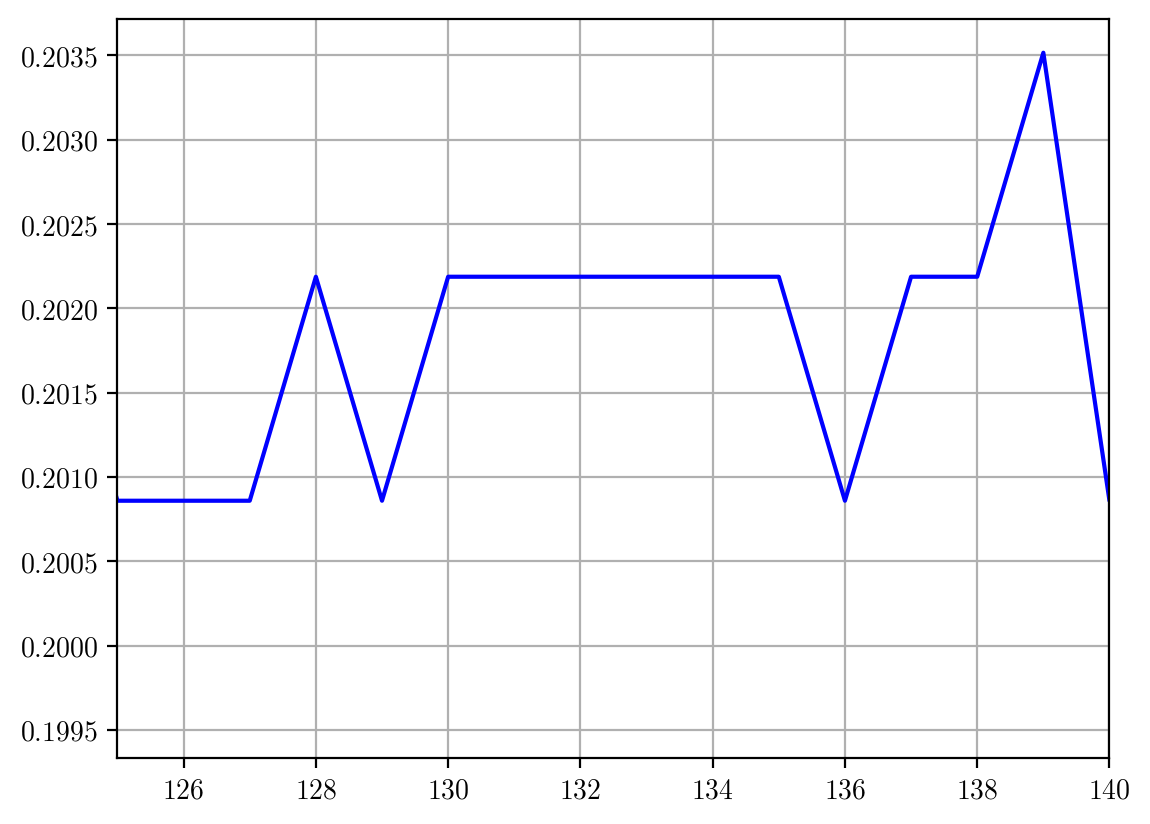

In [4]:
plot([freq_estimator(c.time_domain[i], method='brute') for i in range(200)], xlim=(125, 140))

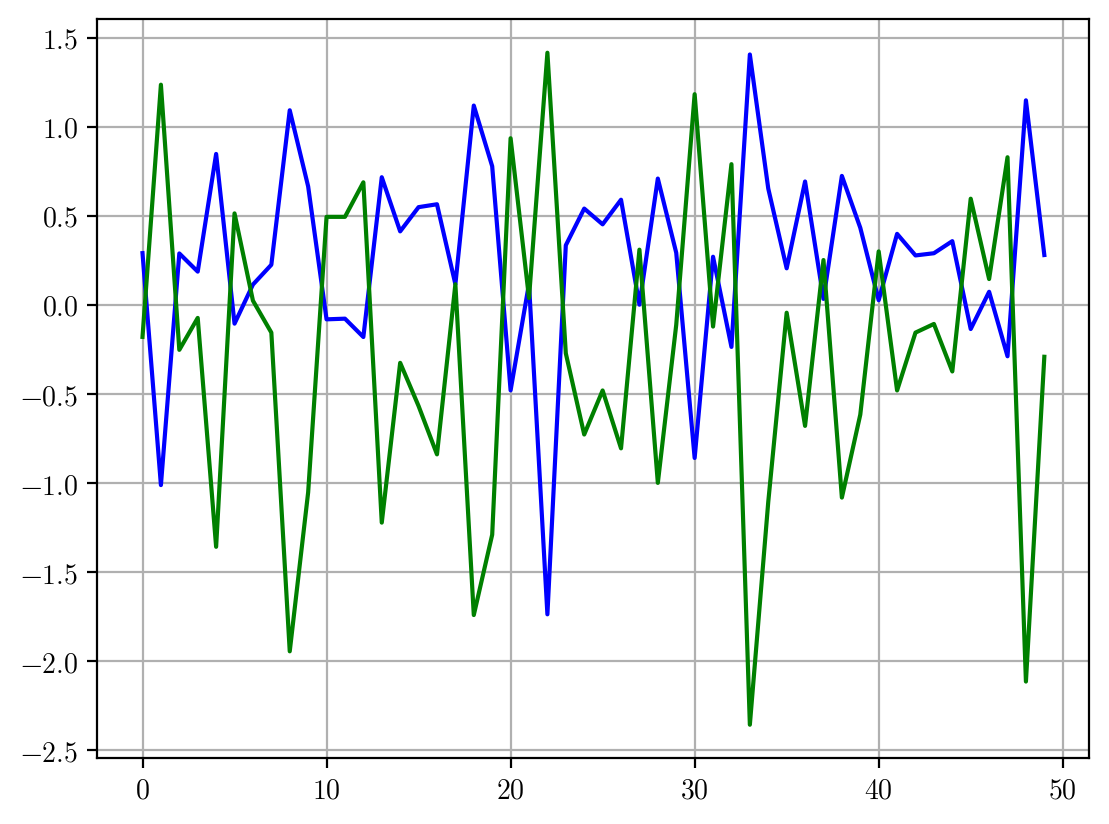

In [2]:
c2 = LoadEstimates(rf'__estimates__.old\noisy\spade_5px\spade_5px_f0.2_d{round(j)}.npz')

plot(c.time_domain[133])
plot(c2.time_domain[133])


In [152]:
from scipy.optimize import minimize, curve_fit
from scipy.special import factorial

def _spade_td(data: np.ndarray, background: np.ndarray, method: str):

    temp = qCMOS.convert2photons(data)
    k = temp[..., 0] / temp[..., 1]
    zhou2023 = 2 * SPADE.SIGMA * (1 - np.sqrt(k)) / (1 + np.sqrt(k))

    if method.lower() == 'sub':
        return data[..., 1] - data[..., 0]
    
    elif method.lower() == 'zhou2023':
        return zhou2023
    
    elif method.lower() in ('lse', 'mle'):
        origin_shape = data.shape
        flatten = data.reshape(-1, origin_shape[-1])
        works = flatten.shape[0]

        pn = qCMOS.convert2photons(flatten)
        b = qCMOS.convert2photons(background).mean()
        I0 = (pn - b).sum(-1).mean(0)
        print(I0, b)

        def _uk(k, theta):
            xi = theta / (2 * SPADE.SIGMA)
            return I0/2 * (xi + k)**2 * np.exp(-xi**2) + b
        
        def _grad_nll(frame):
            def wrapper(theta):
                xi = theta / (2 * SPADE.SIGMA)
                k = np.array([-1, 1])
                return - np.sum(frame * np.log(_uk(k, theta)) - _uk(k, theta) - (frame * np.log(frame) - frame)), \
                         np.sum(I0/(2*SPADE.SIGMA) * np.exp(-xi**2)*((xi + k) * (xi**2 + k*xi - 1) * (frame/_uk(k, theta) - 1)))
            return wrapper

        time_domain = []
        for i in range(works):
            if method.lower() == 'mle':
                opt = minimize(_grad_nll(pn[i]), 
                               x0 = np.ravel(zhou2023)[i], 
                               jac = True, 
                               bounds = [(-2*SPADE.SIGMA, 2*SPADE.SIGMA)], 
                               tol = 1e-8, 
                               options = {'maxls': 100, 'maxiter': 800, 'ftol': 1e-8})

                result = [opt.x.item(), None, opt.success, opt.message]

            elif method.lower() == 'lse':
                result = curve_fit(_uk, xdata=np.array([-1, 1]), ydata=pn[i], p0=np.ravel(zhou2023)[i], full_output=True, maxfev=800, xtol=1e-8)
            
            if result[2]:
                time_domain.append(result[0])
            else:
                raise RuntimeError(f'Time-Domain estimator: {method.upper()} is not converged, {result[3]}')
            
        return np.array(time_domain).reshape(*origin_shape[:-1])

    else:
        raise ValueError('spade_method must be sub, zhou2023, lse, or mle')



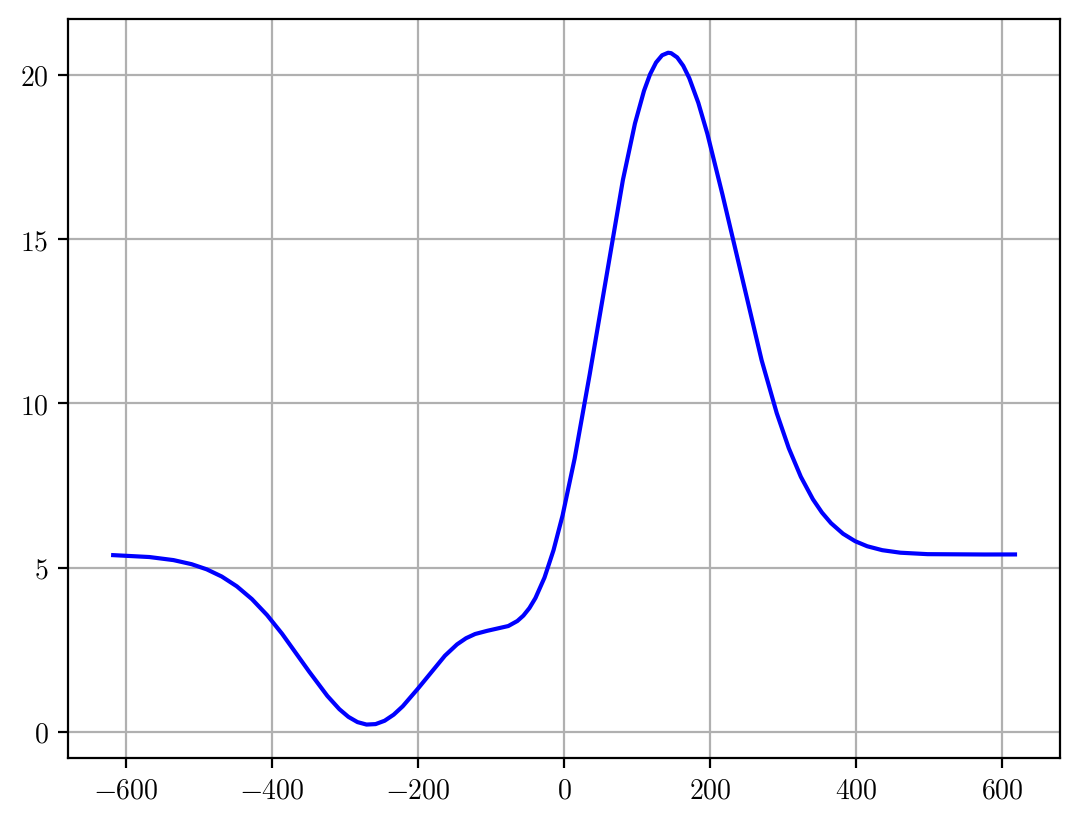

In [166]:

I0 = 58.793534359999995
b = 69.85815782

def _uk(k, theta):
    xi = theta / (2 * SPADE.SIGMA)
    return I0/2 * (xi + k)**2 * np.exp(-xi**2) + b

def _grad_nll(frame):
    def wrapper(theta):
        xi = theta / (2 * SPADE.SIGMA)
        k = np.array([-1, 1])
        return - np.sum(frame * np.log(_uk(k, theta)) - _uk(k, theta) - (frame * np.log(frame) - frame)), \
                 np.sum(I0/(2*SPADE.SIGMA) * np.exp(-xi**2)*((xi + k) * (xi**2 + k*xi - 1) * (frame/_uk(k, theta) - 1)))
    return wrapper


plot((-6*SPADE.SIGMA, 6*SPADE.SIGMA), lambda theta: _grad_nll(qCMOS.convert2photons(c.cropped_data[133, 36]))(theta)[0])
# plot((-2*SPADE.SIGMA, 2*SPADE.SIGMA), lambda theta: _grad_nll(c.cropped_data[133, 36])(theta)[1])


def lsloss(theta):
    return np.sum((_uk(np.array([-1, 1]), theta) - qCMOS.convert2photons(c.cropped_data[133, 36]))**2)

# plot((-6*SPADE.SIGMA, 6*SPADE.SIGMA), lsloss)

In [144]:
qCMOS.convert2photons(c.cropped_data[133, 36])

array([98.56, 64.9 ])

In [138]:
minimize(_grad_nll(qCMOS.convert2photons(c.cropped_data[133, 36])), 
        x0 = -21.439702962462427, 
        jac = True, 
        bounds = [(-2*SPADE.SIGMA, 2*SPADE.SIGMA)], 
        tol = 1e-8,
        options = {'maxls': 100, 'maxiter': 800, 'ftol': 1e-8, 'disp': True})

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 1.159795230921361
        x: [-2.060e+02]
      nit: 5
      jac: [ 2.702e-02]
     nfev: 8
     njev: 8
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>

In [120]:
c.metadata.methods

td1 = _spade_td(c.cropped_data, c.background, 'mle')
td2 = _spade_td(c.cropped_data, c.background, 'lse')
td3 = _spade_td(c.cropped_data, c.background, 'zhou2023')
td4 = _spade_td(c.cropped_data, c.background, 'sub')

58.79353435999999 69.85815782
58.79353435999999 69.85815782


In [124]:
td3[133, 36]

-21.439702962462427

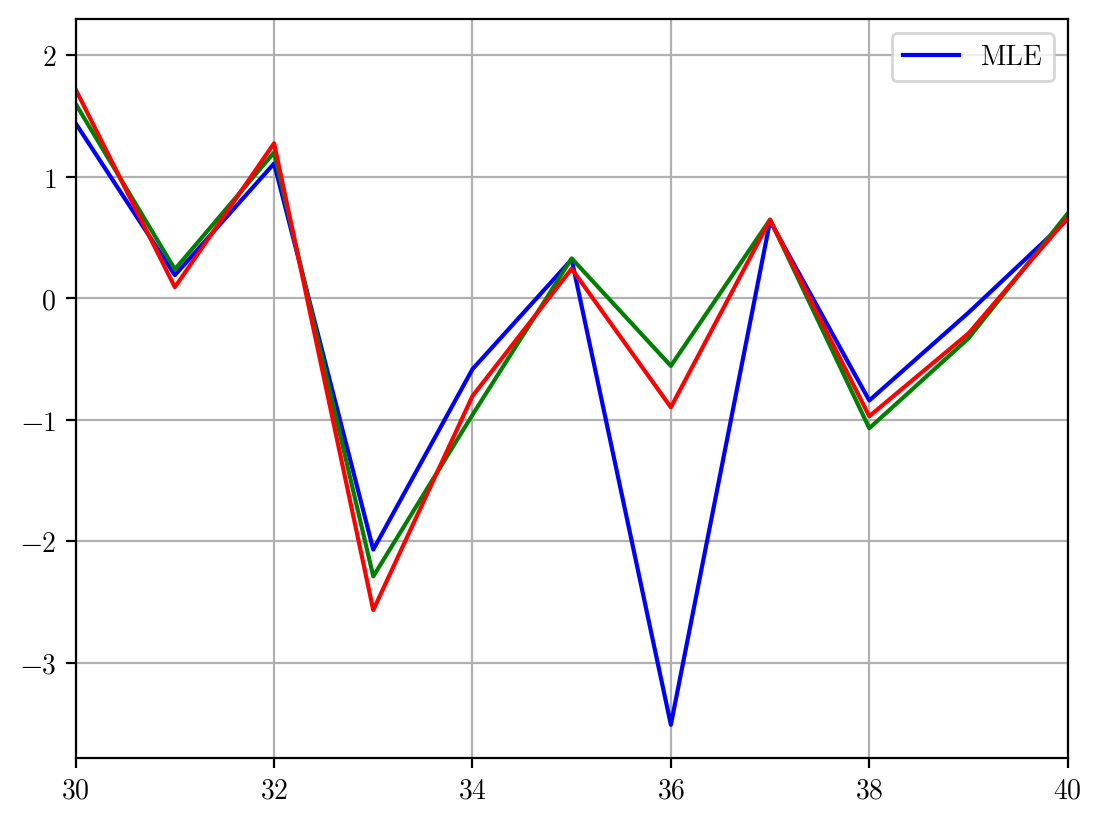

In [170]:
# plot(c.time_domain.mean(0))
# plot(td1.mean(0))
# plot((td2.mean(0)+td1.mean(0))/2)
# plot(td3.mean(0))
# plot(td4.mean(0))

plot(_standardize(td1[133], 1), label='MLE')
plot(_standardize(td2[133], 1), xlim=(30, 40))
plot(_standardize(td3[133], 1))
# plot(td4[133])

In [75]:
qCMOS.convert2photons(data).max() - qCMOS.convert2photons(data).min()

133.10000000000002

In [81]:
data = np.ravel(c.cropped_data.sum(-1))
qCMOS.convert2photons(data).std()

14.501543926682428

In [ ]:
data

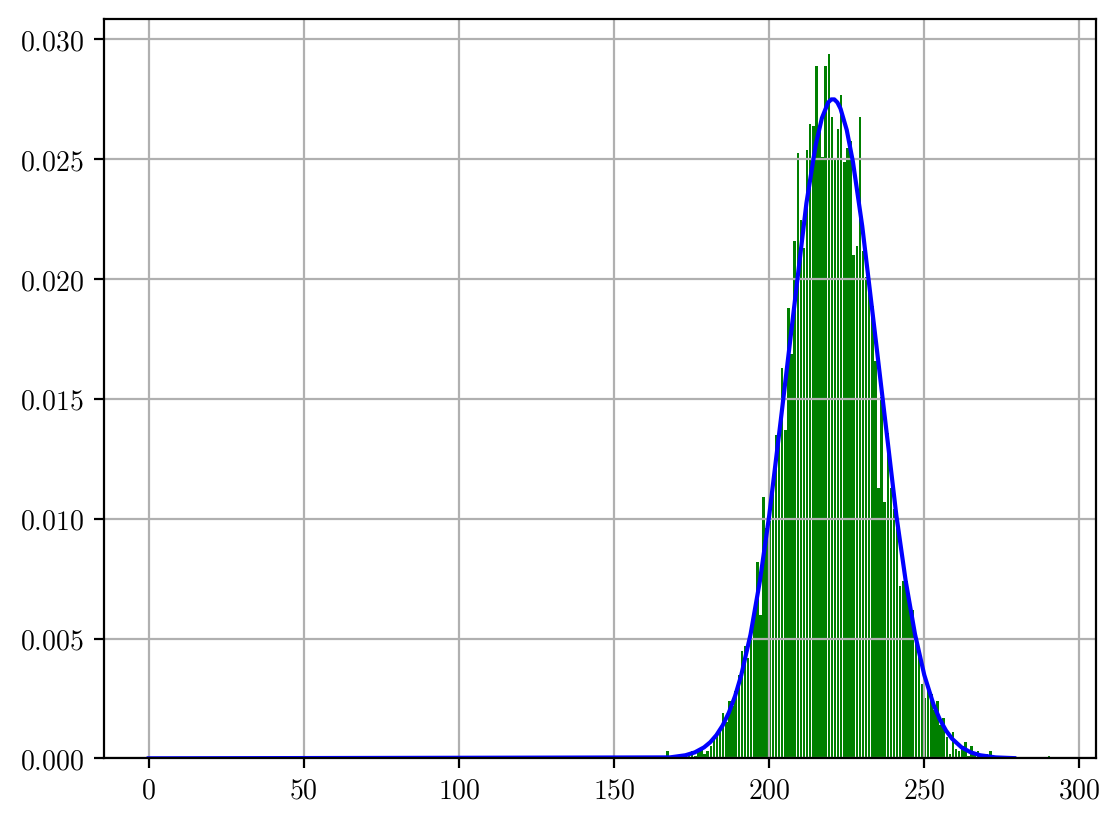

In [83]:
plot(np.arange(280), sp.stats.norm(220.50985, 14.5).pdf)

hist(qCMOS.convert2photons(data), bins=133)

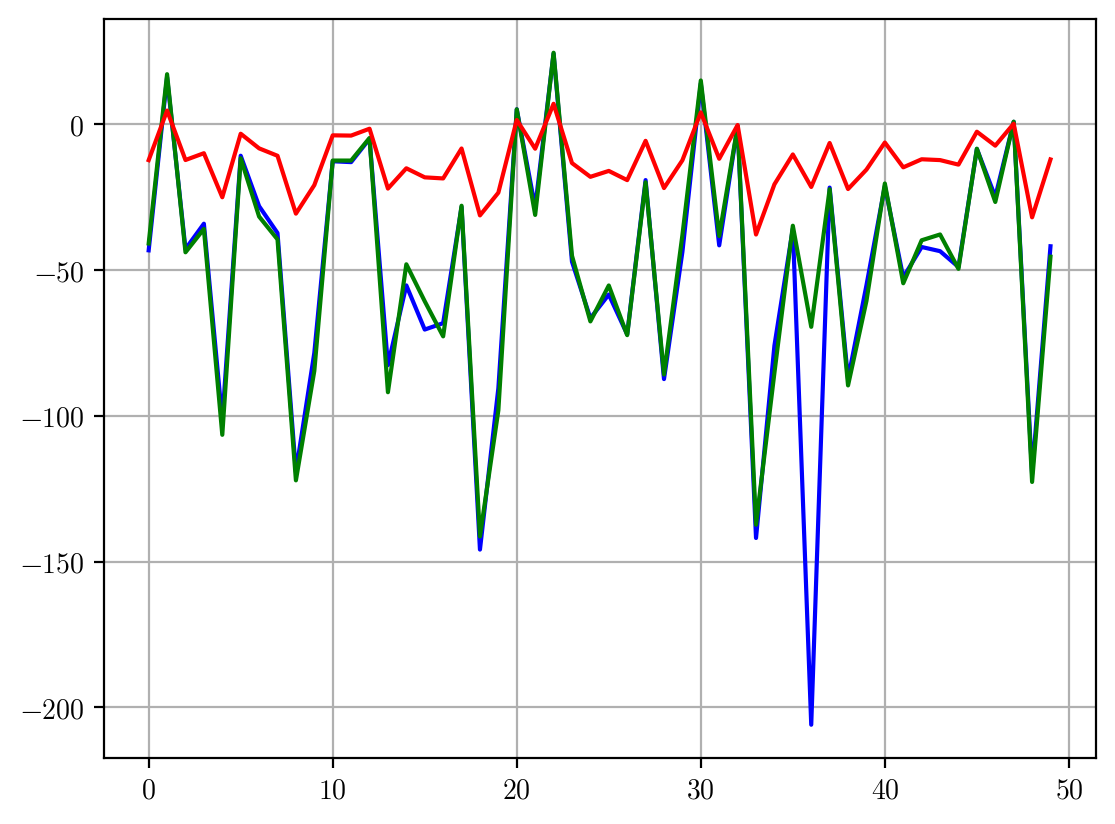

In [41]:
plot(td1[133])
plot(td2[133])
plot(td3[133])

In [25]:
b = 69.85815782

In [26]:
I0 = (198.50985 - 69.85815782 * 2)
I0

58.793534359999995

In [629]:
qCMOS.convert2photons((c.cropped_data - c.background.mean())

36.793534360000024

In [631]:
I0 = 36.793534360000024

In [27]:

def uk(k, theta):
    xi = theta / (2 * SPADE.SIGMA)
    return I0/2 * (xi + k)**2 * np.exp(-xi**2) + b

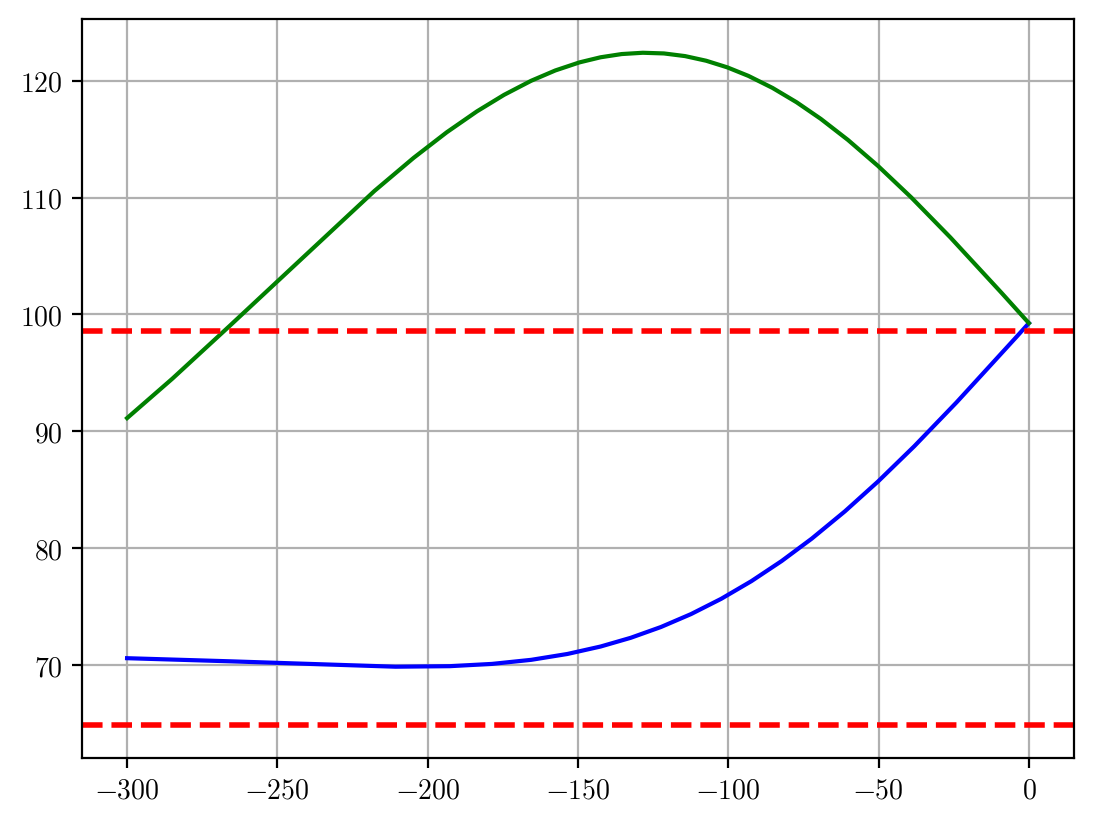

In [29]:
plot((-300, 0), lambda s: uk(1, s))
plot((-300, 0), lambda s: uk(-1, s))
axline(h=98.56)
axline(h=64.9)

In [48]:
qCMOS.convert2photons(c.cropped_data[133, 36])

array([98.56, 64.9 ])

In [572]:
c.metadata.methods

('mle', 'lse')

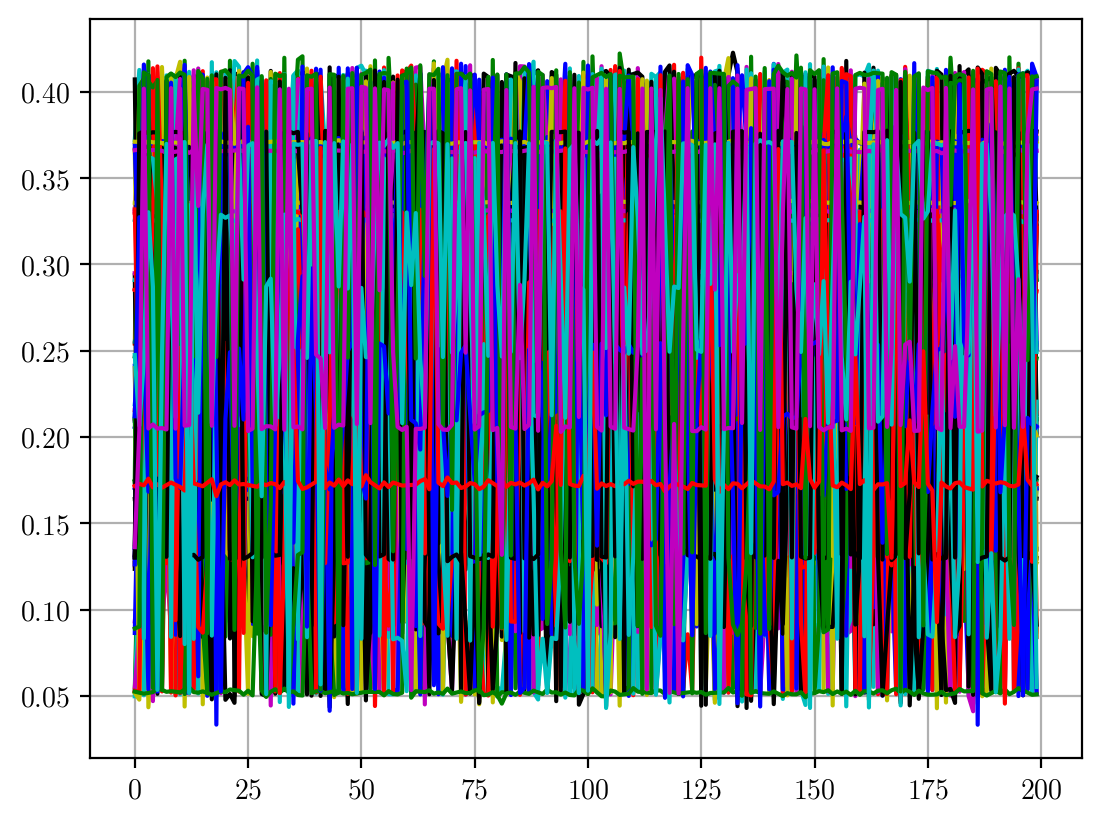

In [532]:
for j in np.linspace(0.1, 0.4, 61):
    c = LoadEstimates(rf'__estimates__\0noise\spade_3px\spade_3px_f{np.round(j, 5)}_d0.npz')
    f_est = [freq_estimator(c.time_domain[i], method='lse') for i in range(200)]

    plot(f_est)

In [473]:
c = LoadEstimates(rf'__estimates__\noisy\spade_5px\spade_5px_f0.2_d{46*2}.npz')

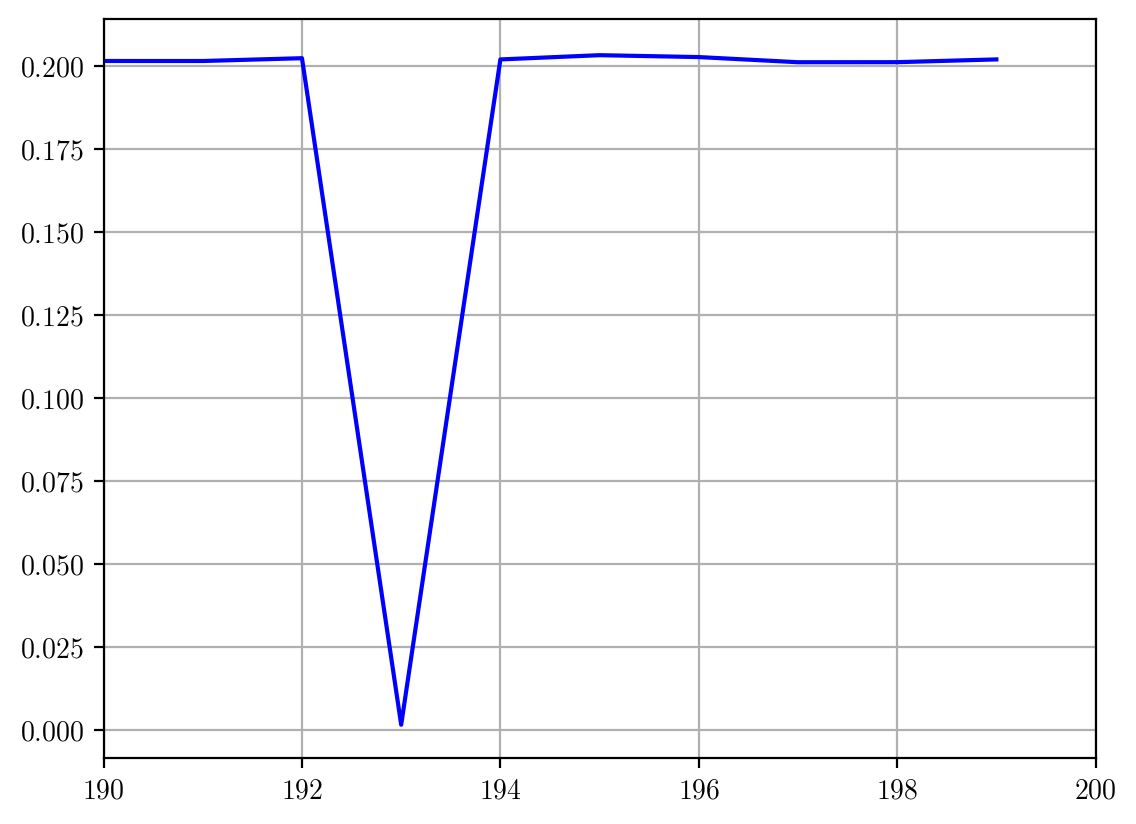

In [474]:
plot([freq_estimator(c.time_domain[i]) for i in range(200)], xlim=(190, 200))

In [472]:
freq_estimator(c.time_domain[193], 'fft')

(0.199288256227758, 0.19750889679715303)

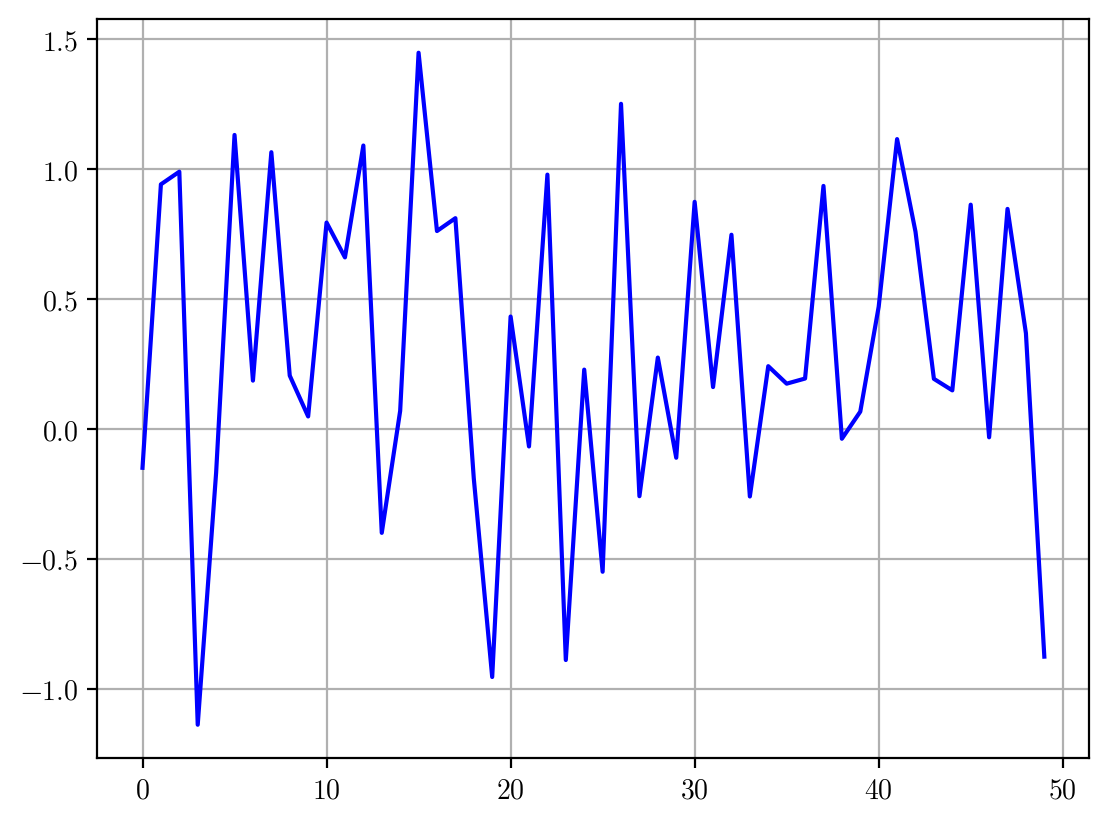

In [475]:
plot(c.time_domain[193])

In [171]:
from src import *

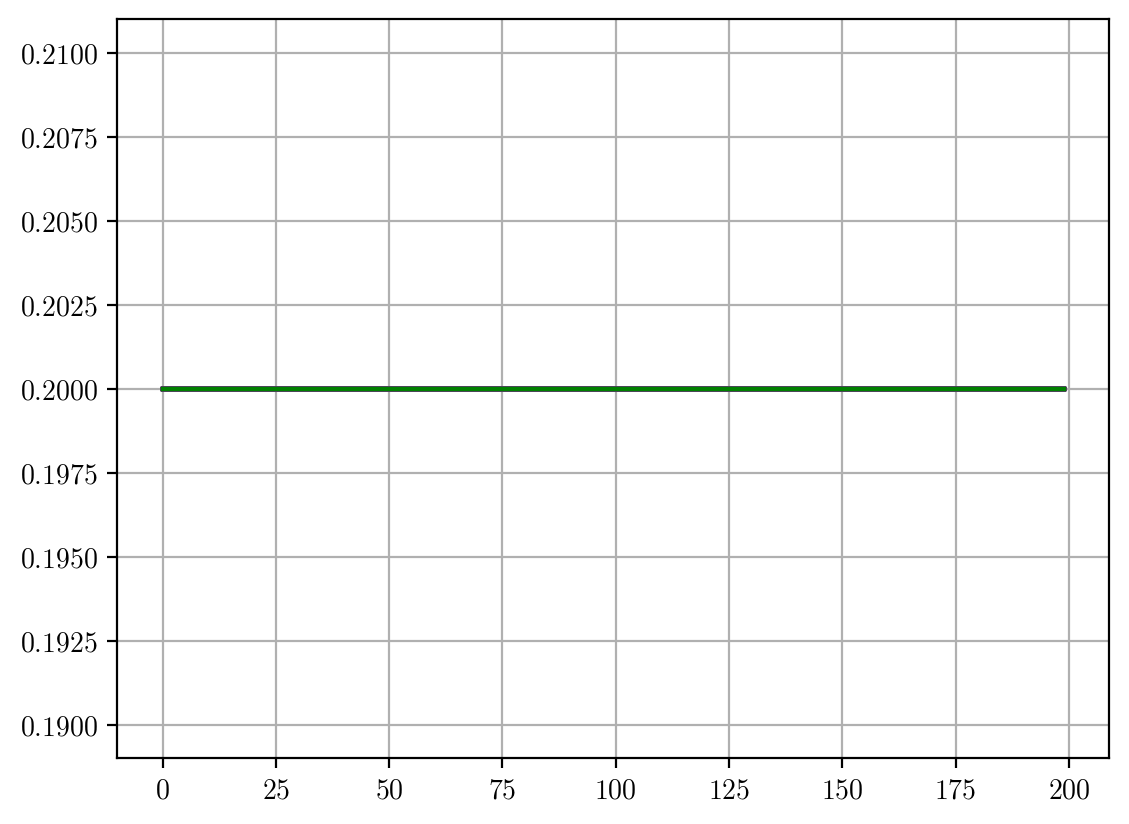

In [210]:
for i in range(51):
    c = LoadEstimates(rf'__estimates__\noisy\di_5px\di_5px_f0.2_d{i*2}.npz')
    plot([freq_estimator(c.time_domain[i], method='fft', zero_padding=0, window_type='none') for i in range(200)])

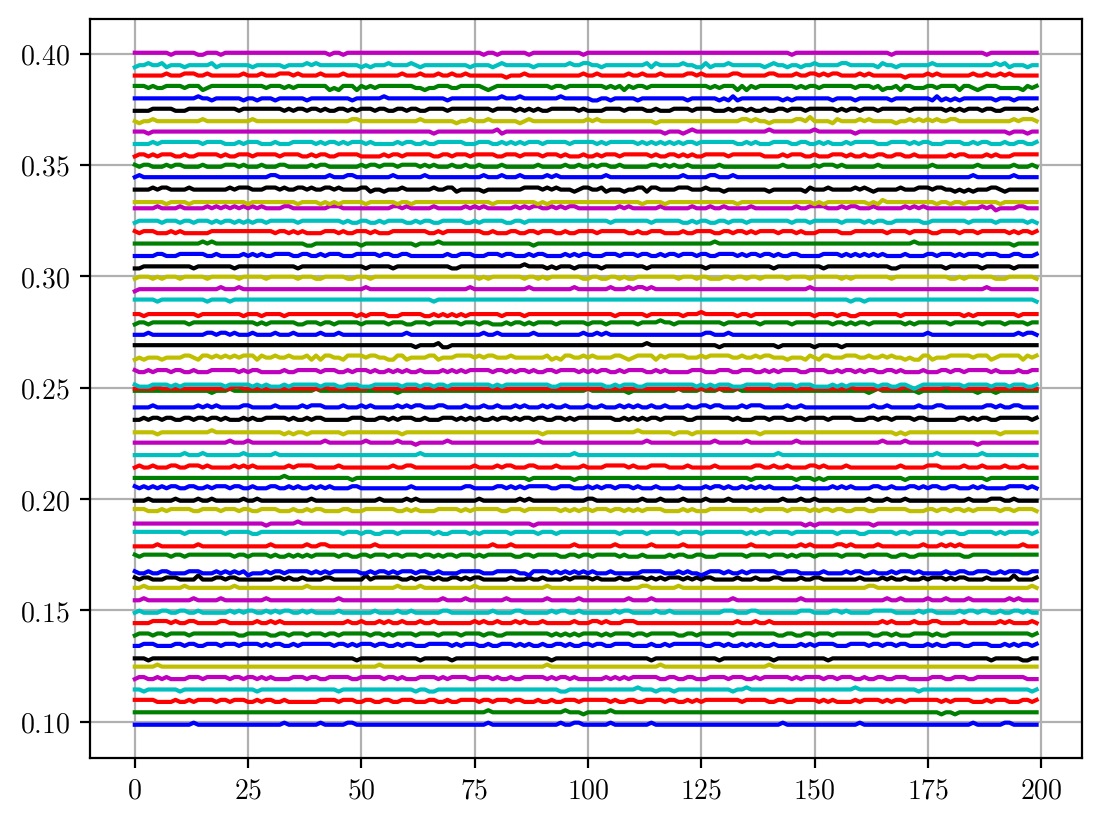

In [214]:
for i in np.linspace(0.1, 0.4, 61):
    c = LoadEstimates(rf'__estimates__\0noise\di_5px\di_5px_f{np.round(i, 5)}_d0.npz')
    plot([freq_estimator(c.time_domain[i], method='fft', zero_padding=1024, window_type='none') for i in range(200)])

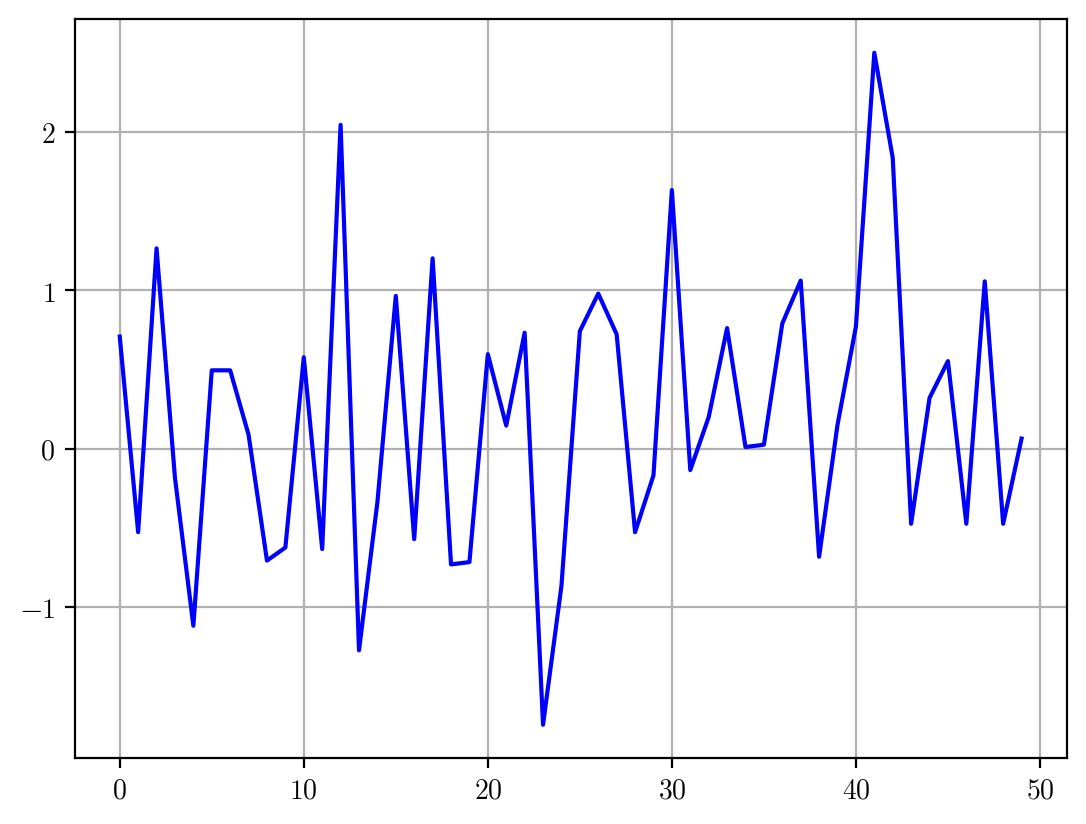

In [191]:
plot(c.time_domain[144])

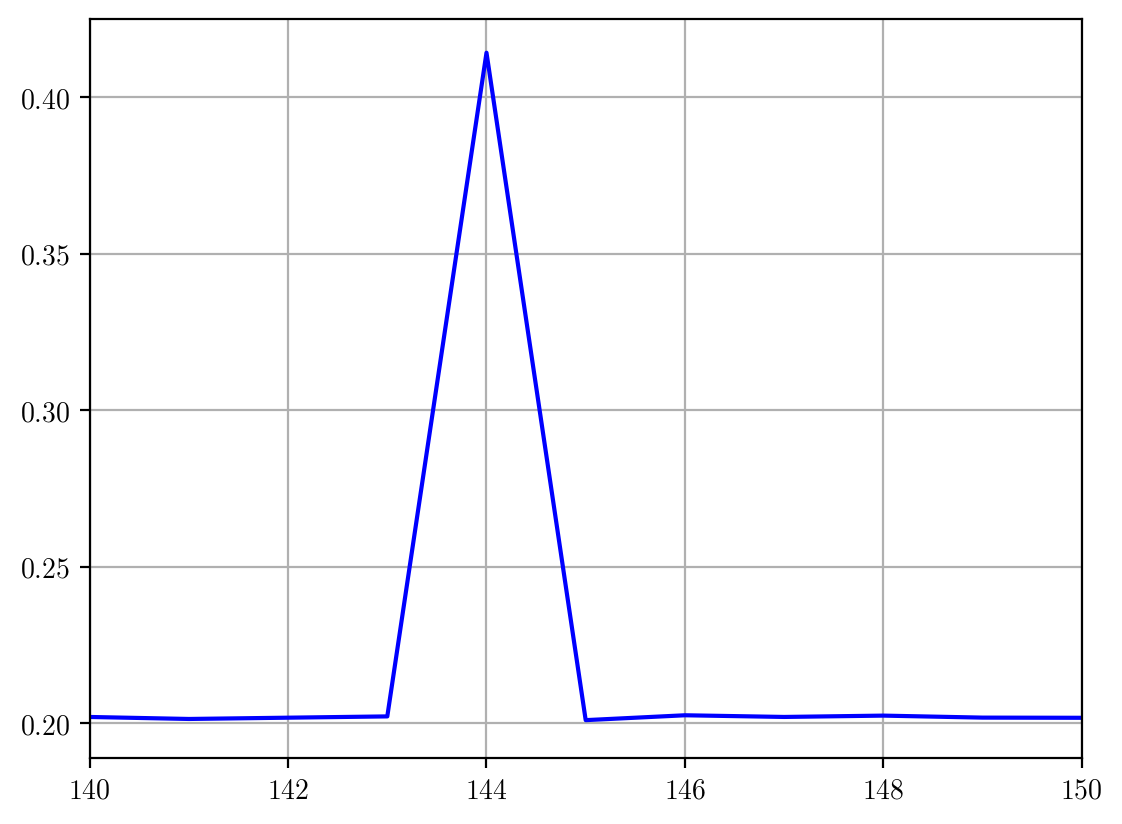

In [189]:
plot(c.estimates_a, xlim=(140, 150))